In [97]:
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(precision=3, floatmode='maxprec_equal')

import os

from datetime import datetime

from hardware_detection import setup_compute_environment
setup_compute_environment()

import optree
import keras
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.models import Sequential
from keras.regularizers import l1_l2
from keras.saving import register_keras_serializable
from keras import ops


import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

from sklearn.model_selection import train_test_split

from keras.callbacks import EarlyStopping
import keras.backend as K


import pickle
from pathlib import Path
import yaml


Detected Apple Silicon GPU, using Metal Performance Shaders


In [2]:
print(f'{optree.__version__ = }')
print(f'{keras.__version__ = }')
print(f"{np.version.version = }")
print(f"{tf.__version__ = }")

optree.__version__ = '0.17.0'
keras.__version__ = '3.11.3'
np.version.version = '2.0.2'
tf.__version__ = '2.18.1'


In [3]:
beta = 4
ndim = 1
n_boot_samples = 2
random_seed = 1
rng = np.random.default_rng(seed=random_seed)

resolution_sf = 1.00
output_dir = Path(f'output-run-nn-study-nd-v1a-ndim{ndim}-res-sf-{resolution_sf:.2f}')
os.makedirs(output_dir, exist_ok=True)
precision = np.single


In [4]:
@register_keras_serializable(name="parametric_gelu")
def parametric_gelu(x, beta=1.0):
    x = ops.convert_to_tensor(x)
    dtype = x.dtype
    beta_const = ops.cast(beta, dtype)
    sqrt2 = ops.cast(ops.sqrt(2.0), dtype)
    return 0.5 * x * (1.0 + ops.erf(beta_const * x / sqrt2))

## Set model and resolution parameters

In [6]:
match ndim:
    case 6:
        mc_mu = np.array([1., 0., -0.5, 0.5, -1., 0.3], dtype=precision)
        mc_rho = [
            np.array([0.0, 0.0, -0.3, 0.2, 0.1], dtype=precision),
            np.array([0.1, 0.3, -0.2, 0.0], dtype=precision),
            np.array([0.3, -0.2, 0.1], dtype=precision),
            np.array([0.0, 0.1], dtype=precision),
            np.array([0.7], dtype=precision),
        ]
        mc_sig = np.array([1., 0.7, 1.1, 0.8, 1.2, 1.4], dtype=precision)

        true_mu = np.array([0.8, 0.1, -0.6, 0.7, -0.8, 0.1], dtype=precision)
        true_rho = [
            np.array([0.0, 0.1, -0.2, 0.2, 0.0], dtype=precision),
            np.array([0.0, 0.2, -0.1, 0.0], dtype=precision),
            np.array([0.4, -0.3, 0.0], dtype=precision),
            np.array([0.0, 0.2], dtype=precision),
            np.array([0.5], dtype=precision),
        ]
        true_sig = np.array([0.8, 0.6, 1.0, 0.6, 1.0, 1.1], dtype=precision)
        resolution = np.array([0.4, 0.5, 0.6, 0.3, 0.4, 0.4], dtype=precision)

    case 4:
        mc_mu = np.array([1., 0., -0.5, 0.5], dtype=precision)
        mc_rho = [
            np.array([0.3, -0.2, 0.1], dtype=precision),
            np.array([0.0, 0.1], dtype=precision),
            np.array([0.7], dtype=precision),
        ]
        mc_sig = np.array([1., 0.7, 1.1, 0.8], dtype=precision)

        true_mu = np.array([0.8, 0.1, -0.6, 0.7], dtype=precision)
        true_rho = [
            np.array([0.4, -0.3, 0.0], dtype=precision),
            np.array([0.0, 0.2], dtype=precision),
            np.array([0.5], dtype=precision),
        ]
        true_sig = np.array([0.8, 0.6, 1.0, 0.6], dtype=precision)
        resolution = np.array([0.4, 0.5, 0.6, 0.3], dtype=precision)

    case 2:
        mc_mu = np.array([0.0, 1.0], dtype=precision)
        mc_rho = [np.array([-0.6], dtype=precision)]
        mc_sig = np.array([1.0, 1.5], dtype=precision)

        true_mu = np.array([0.2, 0.8], dtype=precision)
        true_rho = [np.array([-0.6], dtype=precision)]
        true_sig = np.array([0.9, 1.3], dtype=precision)
        resolution = np.array([0.5, 0.8], dtype=precision)

    case 1:
        mc_mu = np.array([0.0], dtype=precision)
        mc_rho = [np.array([], dtype=precision)]
        mc_sig = np.array([1.0], dtype=precision)

        true_mu = np.array([0.2], dtype=precision)
        true_rho = [np.array([], dtype=precision)]
        true_sig = np.array([0.9], dtype=precision)
        resolution = np.array([0.5], dtype=precision)

# Scale the resolution
resolution *= resolution_sf
print(f'{resolution = }')

def build_cov(sig, rho_rows, *, precision=np.single, verbose=False):
    """
    Construct a covariance matrix:
    Args:
      - sig: 1D sequence of standard deviations (len = n)
      - rho_rows: list of length n-1; entry i is a sequence of length (n - i - 1)
                  containing the correlations for row i
    Returns: (n, n) covariance matrix with dtype=precision.
    """
    n = sig.size
    # Correlation matrix
    C = np.eye(n, dtype=precision)
    for i, r in enumerate(rho_rows):
        expected = n - i - 1
        if r.size != expected:
            raise ValueError(f"rho[{i}] has length {r.size}, expected {expected}")
        C[i, i+1:] = r[::-1]

    # Symmetrize (upper written; mirror to lower)
    C += C.T - np.eye(n, dtype=precision)

    # Covariance via elementwise scale: Σ = (σ σᵀ) ⊙ C
    cov = np.outer(sig, sig).astype(precision, copy=False) * C

    if verbose:
        for i in range(n):
            print(f"  {i:2d}, {i:2d} : diagonal  {cov[i, i]:8.4f}")
            for j in range(i+1, n):
                print(f"  {i:2d}, {j:2d} : {sig[i]:8.3f} * {sig[j]:8.3f} * {C[i, j]:8.3f} = {cov[i, j]:8.4f}")
    return cov

print("MC covariance:")
mc_cov   = build_cov(mc_sig,   mc_rho,   precision=precision, verbose=True)
print("True covariance:")
true_cov = build_cov(true_sig, true_rho, precision=precision, verbose=True)

resolution = array([0.5], dtype=float32)
MC covariance:
   0,  0 : diagonal    1.0000
True covariance:
   0,  0 : diagonal    0.8100


In [7]:
ngen_mc = 10**5
ngen_true =  10**4

of_niter = 5
learning_rate_setval = 0.0005
epochs_setval = 50
patience_setval = -1
restore_best_weights_setval = False

l1reg_kernel_setval = 0.0
l2reg_kernel_setval = 0.0
l1reg_activation_setval = 0.0
l2reg_activation_setval = 0.0
l1reg_bias_setval = 0.0
l2reg_bias_setval = 0.0

use_batch_norm = False
units_per_layer = 50
number_of_layers = 3
dropout_setval = 0.0
batch_size_setval = int( ngen_true )
#activation_setval = 'relu'
activation_setval = parametric_gelu
do_bootstrap = False
use_poisson_fluctuations_around_ngen_true = True
n_models_to_ensemble = 10
save_step2_model = False

In [8]:
print(f"{np.linalg.det(mc_cov) = }")
print(f"{np.linalg.det(true_cov) = }")

np.linalg.det(mc_cov) = np.float32(1.0)
np.linalg.det(true_cov) = np.float32(0.80999994)


In [9]:
mc_cov_inv = np.linalg.inv(mc_cov)
mc_cov_inv_test = mc_cov @ mc_cov_inv
true_cov_inv = np.linalg.inv(true_cov)
true_cov_inv_test = true_cov @ true_cov_inv

In [10]:
print(f"{mc_cov = }")
print(f"{mc_cov_inv = }")
print(f"{mc_cov_inv_test = }")

print(f"\n{true_cov = }")
print(f"{true_cov_inv = }")
print(f"{true_cov_inv_test = }")


mc_cov = array([[1.]], dtype=float32)
mc_cov_inv = array([[1.]], dtype=float32)
mc_cov_inv_test = array([[1.]], dtype=float32)

true_cov = array([[0.81]], dtype=float32)
true_cov_inv = array([[1.235]], dtype=float32)
true_cov_inv_test = array([[1.]], dtype=float32)


## Generate samples, save events and config

In [11]:
mc_pts = rng.multivariate_normal(mc_mu, mc_cov, size=ngen_mc)
true_pts = rng.multivariate_normal(true_mu, true_cov, size=ngen_true)

mc_det_pts = rng.normal( mc_pts, resolution )
true_det_pts = rng.normal( true_pts, resolution )


true_pts10x = rng.multivariate_normal(true_mu, true_cov, size=ngen_true*40)
true_det_pts10x = rng.normal( true_pts10x, resolution )
true_pts10x_weights = np.ones( ngen_true*40 )
true_pts10x_weights = (1./40.) * true_pts10x_weights

In [13]:
np.savez( output_dir/'mc-and-true-samples.npz',
    mc_pts=mc_pts,
    mc_det_pts=mc_det_pts,
    true_pts=true_pts,
    true_det_pts=true_det_pts,
    true_pts10x=true_pts10x,
    true_det_pts10x=true_det_pts10x,
    true_pts10x_weights=true_pts10x_weights,
)
config_pars = {
    'mc_mu': mc_mu,
    'mc_rho': mc_rho,
    'mc_sig': mc_sig,
    'true_mu': true_mu,
    'true_rho': true_rho,
    'true_sig': true_sig,
    'resolution': resolution,
    'mc_cov': mc_cov,
    'true_cov': true_cov,
}
with open(output_dir/'config-pars.pkl', 'wb') as f :
    pickle.dump(config_pars, f)

config_data = {
    'timestamp': datetime.now().isoformat(),
    'generation': {
        'ngen_mc': ngen_mc,
        'ngen_true': ngen_true,
        'of_niter': of_niter,
        'ndim': ndim,
        'random_seed': random_seed,
        'use_poisson_fluctuations_around_total': use_poisson_fluctuations_around_ngen_true
    },
    'training': {
        'learning_rate': learning_rate_setval,
        'epochs': epochs_setval,
        'batch_size': batch_size_setval,
        'patience': patience_setval,
        'restore_best_weights': restore_best_weights_setval,
        'n_models_to_ensemble': n_models_to_ensemble
    },
    'regularization': {
        'l1reg_kernel': l1reg_kernel_setval,
        'l2reg_kernel': l2reg_kernel_setval,
        'l1reg_activation': l1reg_activation_setval,
        'l2reg_activation': l2reg_activation_setval,
        'l1reg_bias': l1reg_bias_setval,
        'l2reg_bias': l2reg_bias_setval
    },
    'model': {
        'activation': activation_setval,
        'beta': beta
    },
    'parameters': {
        'mc': {'mu': mc_mu, 'rho': mc_rho, 'sig': mc_sig, 'cov': mc_cov},
        'true': {'mu': true_mu, 'rho': true_rho, 'sig': true_sig, 'cov': true_cov},
        'resolution': {'sf': resolution_sf, 'values': resolution}
    }
}

with open(f'{output_dir}/config.yaml', 'w') as f:
    yaml.dump(config_data, f, default_flow_style=False, indent=2)


## Plots to visualize these parameter choices

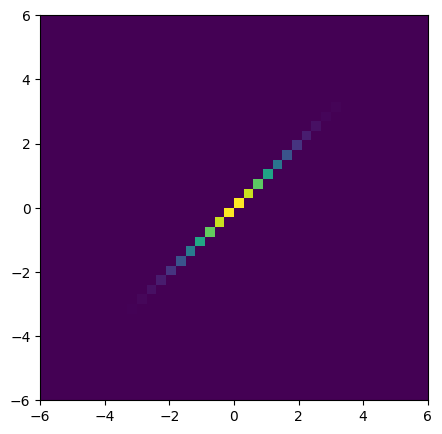

In [15]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim == 1 :
            axi = ax
        else :
            axi = ax[i][j]
        axi.hist2d( mc_pts[:,i], mc_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))
plt.show()

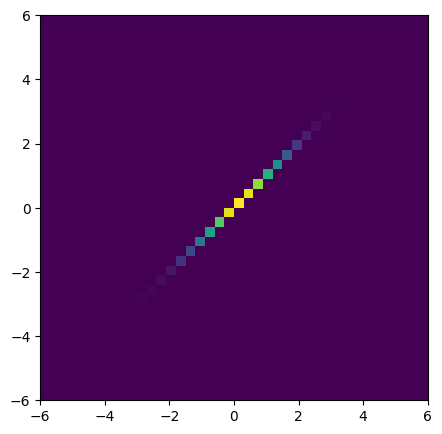

In [16]:
fig,ax = plt.subplots( ndim, ndim, figsize=(ndim*5, ndim*5))

hmin=-6
hmax=6
hbins=40

for i in range(ndim) :
    for j in range(ndim) :
        if j < i : continue
        if ndim == 1 :
            axi = ax
        else :
            axi = ax[i][j]
        axi.hist2d( true_pts[:,i], true_pts[:,j], bins=[hbins,hbins], range=([hmin,hmax],[hmin,hmax]))
plt.show()

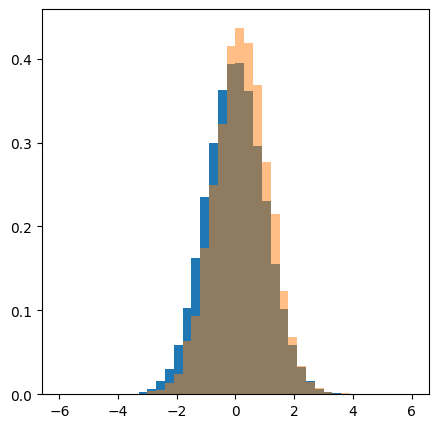

In [17]:
fig,ax = plt.subplots( 1, ndim, figsize=(ndim*5,5))

hmin=-6
hmax=6
hbins=40


for i in range(ndim) :
        k = i*3 + j
        if ndim == 1 :
            axi = ax
        else :
            axi = ax[i]
        axi.hist( mc_pts[:,i],bins=hbins, range=[hmin,hmax], density=True )
        axi.hist( true_pts[:,i],bins=hbins, range=[hmin,hmax], density=True, alpha=0.5 )
plt.show()

### Calculate true weights analytically and compare with unfolding output weights.

In [18]:
mc_pts_minus_mc_mu = mc_pts - mc_mu
mc_pts_minus_true_mu = mc_pts - true_mu
true_cov_inv_times_v = np.tensordot( true_cov_inv, mc_pts_minus_true_mu.T, axes=(1,0) )
v_times_true_cov_inv_times_v =  np.sum( mc_pts_minus_true_mu.T * true_cov_inv_times_v, axis=0)
mc_cov_inv_times_v = np.tensordot( mc_cov_inv, mc_pts_minus_mc_mu.T, axes=(1,0) )
v_times_mc_cov_inv_times_v =  np.sum( mc_pts_minus_mc_mu.T * mc_cov_inv_times_v, axis=0)
exp_v_times_mc_cov_inv_times_v = np.exp( -0.5 * v_times_mc_cov_inv_times_v )
exp_v_times_true_cov_inv_times_v  = np.exp( -0.5 * v_times_true_cov_inv_times_v  )
true_cov_det = np.linalg.det( true_cov )
mc_cov_det = np.linalg.det( mc_cov )
norm2_true = np.power( 3.14159265, ndim) * true_cov_det
print("\n norm2_true : %f\n" % norm2_true )
norm2_train = np.power( 3.14159265, ndim) * mc_cov_det
print("\n norm2_train : %f\n" % norm2_train )
pdf_train = exp_v_times_mc_cov_inv_times_v / np.sqrt(norm2_train)
print(pdf_train)
pdf_true = exp_v_times_true_cov_inv_times_v / np.sqrt(norm2_true)
print(pdf_true)
pdf_ratio = pdf_true / pdf_train
sample_sf = (1.*len(true_pts))/(1.*len(mc_pts))
print('\n sample_sf = %f' % sample_sf )
calc_weight = pdf_ratio
calc_weight_scaled = sample_sf * pdf_ratio
print('\n Calculated weights :  %s\n' % str(calc_weight))


 norm2_true : 2.544690


 norm2_train : 3.141593

[0.531 0.403 0.534 ... 0.208 0.562 0.353]
[0.619 0.494 0.620 ... 0.126 0.596 0.435]

 sample_sf = 0.100000

 Calculated weights :  [1.164 1.227 1.161 ... 0.605 1.060 1.233]



## Set up NN model for OmniFold

In [88]:
def weighted_binary_crossentropy(y_true, y_pred):
    weights = tf.gather(y_true, [1], axis=1) # event weights
    y_true = tf.gather(y_true, [0], axis=1) # actual y_true for loss

    # Clip the prediction value to prevent NaN's and Inf's
    epsilon = K.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

    t_loss = -weights * ((y_true) * tf.math.log(y_pred) +
                         (1 - y_true) * tf.math.log(1 - y_pred))

    return tf.reduce_mean(t_loss)

In [89]:
reg_setval_zero = 0.0
model_step1 = Sequential([
    Input(shape=(ndim,)),
    Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) )
], name="model_step1"
)
if use_batch_norm : model_step1.add( BatchNormalization() )
model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step1.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step1.add( BatchNormalization() )
    model_step1.add( Dropout(dropout_setval) )

model_step1.add( Dense(1, activation='sigmoid') )





model_step2 = Sequential([
    Input(shape=(ndim,)),
    Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval), 
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) )
], name="model_step2"
)
if use_batch_norm : model_step2.add( BatchNormalization() )
model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 1 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

if number_of_layers > 2 :
    model_step2.add( Dense(units_per_layer, activation=activation_setval, 
                       kernel_regularizer=l1_l2(l1reg_kernel_setval, l2reg_kernel_setval), 
                       bias_regularizer=l1_l2(l1reg_bias_setval, l2reg_bias_setval),
                       activity_regularizer=l1_l2(l1reg_activation_setval, l2reg_activation_setval) ) )
    if use_batch_norm : model_step2.add( BatchNormalization() )
    model_step2.add( Dropout(dropout_setval) )

model_step2.add( Dense(1, activation='sigmoid') )
opt_step1 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )
opt_step2 = tf.keras.optimizers.Adam( learning_rate=learning_rate_setval )



model_step1.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step1,
                      metrics=['accuracy'])

model_step2.compile(loss=weighted_binary_crossentropy,
                      optimizer=opt_step2,
                      metrics=['accuracy'])

model_step1.summary()

model_step2.summary()


Model: "model_step1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

Model: "model_step2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

## Show some model structure details

In [90]:
for li, layer in enumerate(model_step1.layers) :
    print(f"layer {li} : {layer.name}")
    if 'dropout' not in layer.name :
        for weight in layer.get_weights() :
            print( f'\t{weight.shape = }' )
            print( f'\t\tRange {np.min(weight):.3f} to {np.max(weight):.3f}')

layer 0 : dense_57
	weight.shape = (1, 50)
		Range -0.333 to 0.322
	weight.shape = (50,)
		Range 0.000 to 0.000
layer 1 : dropout_42
layer 2 : dense_58
	weight.shape = (50, 50)
		Range -0.245 to 0.245
	weight.shape = (50,)
		Range 0.000 to 0.000
layer 3 : dropout_43
layer 4 : dense_59
	weight.shape = (50, 50)
		Range -0.245 to 0.245
	weight.shape = (50,)
		Range 0.000 to 0.000
layer 5 : dropout_44
layer 6 : dense_60
	weight.shape = (50, 1)
		Range -0.335 to 0.332
	weight.shape = (1,)
		Range 0.000 to 0.000


## Define and test function to reset the model weights

In [91]:
def reset_model_weights( model, verb=False ) :
    print('Resetting weights for model %s' % model)
    for li in range(len(model.layers)) :
        if verb : print( ' \n layer index %2d : name = %s' % (li, model.layers[li].name) )
        if 'dropout' in model.layers[li].name : continue
        weights, biases = model.layers[li].get_weights()
        weight_shape_sum = np.sum( weights.shape )
        weight_max = np.sqrt(6/weight_shape_sum)
        weight_min = -1 * weight_max
        new_weights = np.random.uniform( weight_min, weight_max, weights.shape )
        if verb :
            print( ' %3d : weights shape %s, sum %d, range [%.3f,%.3f], biases shape %s' % 
                  (li, str(weights.shape), weight_shape_sum, 
                   weight_min, weight_max, str(biases.shape)))
            print( ' old weights: %s  %s' % (str(weights.shape), str(weights) ) )
            print( ' new weights: %s  %s' % (str(new_weights.shape), str(new_weights) ) )
        new_biases = np.zeros( biases.shape )
        model.layers[li].set_weights( (new_weights, new_biases) )

In [92]:
reset_model_weights( model_step1, True )

Resetting weights for model <Sequential name=model_step1, built=True>
 
 layer index  0 : name = dense_57
   0 : weights shape (1, 50), sum 51, range [-0.343,0.343], biases shape (50,)
 old weights: (1, 50)  [[-0.146  0.157 -0.011 -0.046 -0.076  0.177  0.042 -0.028  0.113  0.322
  -0.200 -0.226  0.020  0.295 -0.300 -0.188  0.040 -0.112 -0.152 -0.073
  -0.333  0.231 -0.032 -0.327  0.187  0.070 -0.080  0.216  0.302  0.184
   0.314  0.220  0.306  0.257 -0.040 -0.210  0.077 -0.138  0.043  0.285
  -0.201  0.159 -0.233  0.227  0.177  0.179 -0.251  0.080 -0.062 -0.093]]
 new weights: (1, 50)  [[-0.117 -0.262  0.073 -0.093  0.168 -0.095 -0.180 -0.103 -0.025 -0.047
   0.255  0.335  0.319 -0.093 -0.170 -0.259 -0.331 -0.148 -0.302 -0.222
  -0.249  0.275  0.341 -0.224  0.091 -0.173  0.049 -0.239  0.070 -0.029
   0.327  0.019 -0.062 -0.038  0.020  0.036 -0.192 -0.278  0.192  0.110
  -0.319  0.246 -0.161  0.023  0.261 -0.233  0.090 -0.237  0.174 -0.192]]
 
 layer index  1 : name = dropout_42
 
 laye

## Package the training data for OmniFold

In [93]:
mc_both = np.stack([mc_pts, mc_det_pts], axis=1)

## Define the OmniFold function

In [94]:
def reweight(events,model,batch_size=10000):
    f = model.predict(events, batch_size=batch_size, verbose=0)
    epsilon = K.epsilon()
    f = tf.clip_by_value( f, epsilon, 1. - epsilon )
    weights = f / (1. - f)
    return np.squeeze(np.nan_to_num(weights))


In [95]:
def omnifold(theta0,theta_unknown_S,iterations, model_step1, model_step2, verbose=0,
             batch_size_setval=10000, epochs_setval=20,
             save_step2_model=False, output_dir="./", patience_setval=5,
             restore_best_weights_setval=False):

    ensemble_weights = np.empty(shape=(n_models_to_ensemble, iterations, 2, len(theta0)))

    ensemble_final_push_weights = np.empty( shape=(n_models_to_ensemble, len(theta0)) )
    
    
    weights = np.empty(shape=(iterations, 2, len(theta0)))
    push_weights_for_output = np.empty(shape=(iterations, len(theta0)))

    ensemble_push_weights_for_output = np.empty( shape=(n_models_to_ensemble, iterations, len(theta0)) )

    ensemble_pull_weights_for_output = np.empty( shape=(n_models_to_ensemble, iterations, len(theta0)) )

    theta0_G = theta0[:,0]
    theta0_S = theta0[:,1]

    labels0 = np.zeros(len(theta0))
    labels_unknown = np.ones(len(theta_unknown_S))
    labels_unknown_step2 = np.ones(len(theta0_G))

    premc_xvals_1 = np.concatenate((theta0_S, theta0_S))
    premc_yvals_1 = np.concatenate( (np.ones(len(theta0_S)), np.zeros(len(theta0_S))) )
    xvals_1 = np.concatenate((theta0_S, theta_unknown_S))
    yvals_1 = np.concatenate((labels0, labels_unknown))

    premc_xvals_2 = np.concatenate((theta0_G, theta0_G))
    premc_yvals_2 = np.concatenate( (np.ones(len(theta0_G)), np.zeros(len(theta0_G))) )
    xvals_2 = np.concatenate((theta0_G, theta0_G))
    yvals_2 = np.concatenate((labels0, labels_unknown_step2))

    if verbose :
        print("\n\n")
        print("  ======== omnifold\n\n")
        print("  shape of theta0_S : %s" % str(np.shape(theta0_S)) ) ;
        print("  shape of theta_unknown_S : %s" % str(np.shape(theta_unknown_S)) ) ;
        print("  shape of xvals_1 :  %s" % str(np.shape( xvals_1 )) ) ;
        print("\n\n")
        print("  shape of labels0 : %s" % str(np.shape(labels0)) ) ;
        print("  shape of labels_unknown : %s" % str(np.shape(labels_unknown)) ) ;
        print("  shape of yvals_1 :  %s" % str(np.shape( yvals_1 )) ) ;
        print("\n\n")
        print("  shape of theta0_G : %s" % str(np.shape(theta0_G)) ) ;
        print("  shape of xvals_2 :  %s" % str(np.shape( xvals_2 )) ) ;
        print("  shape of yvals_2 :  %s" % str(np.shape( yvals_2 )) ) ;
        print("\n batch size setval  %d" % batch_size_setval )
        print(" epochs setval  %d" % epochs_setval )
        print("\n\n")

    # initial iterative weights are ones
    weights_pull = np.ones(len(theta0_S))
    weights_push = np.ones(len(theta0_S))


    # owen: rescale the MC weights to balance the two categories for step 1 in first iteration.
    mc_weight_sf = (1.*len(theta_unknown_S))/(1.*len(theta0_S))

    fitverbose = 0
    if verbose > 1 : fitverbose = 1

    return_dict = {}
    
    for ei in range( n_models_to_ensemble ) :


        if (verbose>0) :
            print('\n\n\n ++++++++++++++ Begin Ensemble %2d ++++++++++++++++\n\n' % ei )

        reset_model_weights( model_step1 )  

        reset_model_weights( model_step2 )

        weights_pull = np.ones(len(theta0_S))
        weights_push = np.ones(len(theta0_S))

    
#------------- Begin loop over iterations

        for i in range(iterations):

            if (verbose>0):
                print("\nITERATION: {}\n".format(i + 1))
                pass

            # STEP 1: classify Sim. (which is reweighted by weights_push) to Data
            # weights reweighted Sim. --> Data

            if (verbose>0):
                print("   -- ITERATION %d  STEP 1\n" % (i+1) )
                pass

            print(" weights_push at the beginning")
            print( weights_push )



         # owen: put the scaling here so that weights_push keeps its meaning (order 1).
            weights_1 = np.concatenate((mc_weight_sf * weights_push, np.ones(len(theta_unknown_S))))

            X_mc_1, X_test_1, Y_mc_1, Y_test_1, w_mc_1, w_test_1 = train_test_split(xvals_1, yvals_1, weights_1)

            # zip ("hide") the weights with the labels
            Y_mc_1 = np.stack((Y_mc_1, w_mc_1), axis=1)
            Y_test_1 = np.stack((Y_test_1, w_test_1), axis=1)
            
            
            
            if verbose>0 : print(' Iter %d, step 1, ensemble index %d' % (i, ei) )
            
            
            
            if i > -1 :

                    premc_weights_1 = np.concatenate( (np.ones(len(theta0_S)), np.ones(len(theta0_S))) )

                    pt_X_mc_1, pt_X_test_1, pt_Y_mc_1, pt_Y_test_1, pt_w_mc_1, pt_w_test_1 = train_test_split(premc_xvals_1, premc_yvals_1, premc_weights_1)

                    pt_Y_mc_1 = np.stack((pt_Y_mc_1, pt_w_mc_1), axis=1)
                    pt_Y_test_1 = np.stack((pt_Y_test_1, pt_w_test_1), axis=1)

                    if verbose>0 :
                            print("             running pre-training, distinguish from self.")

                    model_step1.fit( pt_X_mc_1, pt_Y_mc_1, epochs=5, batch_size=batch_size_setval, verbose=False )

                    if verbose>0 :
                            print("             done pretraining.")

                            
                            
                            
                            
            this_epochs = epochs_setval
            if i == 0 : this_epochs = this_epochs*2
        
            earlystopping = EarlyStopping(patience=patience_setval, verbose=True, 
                                          restore_best_weights=restore_best_weights_setval)

            if patience_setval >= 0 :
                cbl = [earlystopping]
            else :
                cbl = []
                
            mc_history_step1 = model_step1.fit(X_mc_1,
                                                  Y_mc_1,
                                                  epochs=this_epochs,
                                                  batch_size=batch_size_setval,
                                                  validation_data=(X_test_1, Y_test_1),
                                                  verbose=fitverbose,
                                                  callbacks=cbl )

            
            ensemble_weights[ei, i, 0, :] = reweight(theta0_S,model_step1)
            
            print(' Ensemble %2d, Iteration %d, step 1, weights' % (ei, i))
            print( ensemble_weights[ei, i, 0, :] )
        
        
            step1_output_weights = reweight(theta0_S,model_step1)
            

            weights_pull = weights_push * step1_output_weights

            weights[i, :1, :] = step1_output_weights

            return_dict["mc-hist-step1-iter%d" % i] = mc_history_step1

            return_dict['model_weights_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[0] )

            return_dict['model_biases_step1_iter%d' % i] = np.copy( model_step1.layers[0].get_weights()[1] )

            ensemble_pull_weights_for_output[ei,i,:] = weights_pull

            # STEP 2: classify Gen. to reweighted Gen. (which is reweighted by weights_pull)
            # weights Gen. --> reweighted Gen.

            if (verbose>0):
                print("\n   -- ITERATION %d  STEP 2\n" % (i+1) )
                pass

            
            if verbose>0 : print(' Iter %d, step 2, ensemble index %d' % (i, ei) )

            # ones for Gen. (not MC weights), actual weights for (reweighted) Gen.
            weights_2 = np.concatenate((   weights_push  , weights_pull))

            X_mc_2, X_test_2, Y_mc_2, Y_test_2, w_mc_2, w_test_2 = train_test_split(xvals_2, yvals_2, weights_2)

            # zip ("hide") the weights with the labels
            Y_mc_2 = np.stack((Y_mc_2, w_mc_2), axis=1)
            Y_test_2 = np.stack((Y_test_2, w_test_2), axis=1)

            if i > -1 :

                    premc_weights_2 = np.concatenate( (np.ones(len(theta0_G)), np.ones(len(theta0_G))) )

                    pt_X_mc_2, pt_X_test_2, pt_Y_mc_2, pt_Y_test_2, pt_w_mc_2, pt_w_test_2 = train_test_split(premc_xvals_2, premc_yvals_2, premc_weights_2)

                    pt_Y_mc_2 = np.stack((pt_Y_mc_2, pt_w_mc_2), axis=1)
                    pt_Y_test_2 = np.stack((pt_Y_test_2, pt_w_test_2), axis=1)

                    if verbose>0 :
                            print("             running pre-training, distinguish from self.")

                    model_step2.fit( pt_X_mc_2, pt_Y_mc_2, epochs=5, batch_size=batch_size_setval, verbose=fitverbose )

                    if verbose>0 :
                            print("             done pretraining.")

            earlystopping = EarlyStopping(patience=patience_setval, verbose=True,
                                          restore_best_weights=restore_best_weights_setval)
            if patience_setval >= 0 :
                cbl = [earlystopping]
            else :
                cbl = []

            mc_history_step2 = model_step2.fit(X_mc_2,
                                                  Y_mc_2,
                                                  epochs=this_epochs,
                                                  batch_size=batch_size_setval,
                                                  validation_data=(X_test_2, Y_test_2),
                                                  callbacks=cbl,
                                                  verbose=fitverbose )

            return_dict["mc-hist-step2-iter%d" % i] = mc_history_step2

            return_dict['model_weights_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[0] )

            return_dict['model_biases_step2_iter%d' % i] = np.copy( model_step2.layers[0].get_weights()[1] )


            ensemble_weights[ei, i, 1, :] = reweight(theta0_G,model_step2)

            print(' Ensemble %2d, Iteration %d, step 2, weights' % (ei, i))
            print( ensemble_weights[ei, i, 1, :] )        


            step2_output_weights = reweight(theta0_G,model_step2)

            weights_push = step2_output_weights * weights_push

            #push_weights_for_output[i] = weights_push
            
            ensemble_push_weights_for_output[ei,i,:] = weights_push

            weights[i, 1:2, :] = step2_output_weights

            if save_step2_model :
                model_output_dir = "%s/of-step2-iter%02d-ensemble%02d-model" % (output_dir, i, ei)
                print("\n +++ Saving step 2, iteration %d model in %s" % (i, model_output_dir) )
                model_step2.save( "%s.keras" % model_output_dir )
                
                
    #----------- End loop over iterations
                
        ensemble_final_push_weights[ei,:] = weights_push
        
    #------- End loop over ensembles

    if verbose>0 :
        print('\n Done with loop over ensembles.  Now averaging final push weights.')

    return_dict["final_push_weights"] = np.average( ensemble_final_push_weights, axis=0 )

    push_weights_for_output = np.average( ensemble_push_weights_for_output, axis=0 )

    pull_weights_for_output = np.average( ensemble_pull_weights_for_output, axis=0 )
    
    return_dict["weights"] = weights
    
    return_dict["ensemble_weights"] = ensemble_weights

    return_dict['ensemble_final_push_weights'] = ensemble_final_push_weights

    return_dict["push_weights"] = push_weights_for_output

    return_dict["pull_weights"] = pull_weights_for_output    
    
    



    
    return return_dict


## Run OmniFold

In [96]:
%%time
verbose = True
of_return_dict = omnifold( 
    mc_both, true_det_pts, of_niter, model_step1, model_step2, verbose, 
    batch_size_setval, epochs_setval,
    save_step2_model, output_dir,
    patience_setval, restore_best_weights_setval
)
of_weights = of_return_dict["weights"]
mc_weight_sf = (1.*len(true_det_pts))/(1.*len(mc_both))
push_weights = of_return_dict["push_weights"]
push_weights_scaled = np.copy( push_weights )
push_weights_scaled = mc_weight_sf * push_weights
pull_weights = of_return_dict["pull_weights"]
final_push_weights = of_return_dict["final_push_weights"]
final_push_weights_scaled = np.copy(final_push_weights)
final_push_weights_scaled = mc_weight_sf * final_push_weights
ensemble_final_push_weights = of_return_dict['ensemble_final_push_weights']
with open( '%s/omnifold-output-weights.npy' % output_dir, 'wb') as f :
    np.save(f, final_push_weights_scaled)





  ======== omnifold


  shape of theta0_S : (100000, 1)
  shape of theta_unknown_S : (10000, 1)
  shape of xvals_1 :  (110000, 1)



  shape of labels0 : (100000,)
  shape of labels_unknown : (10000,)
  shape of yvals_1 :  (110000,)



  shape of theta0_G : (100000, 1)
  shape of xvals_2 :  (200000, 1)
  shape of yvals_2 :  (200000,)

 batch size setval  10000
 epochs setval  50






 ++++++++++++++ Begin Ensemble  0 ++++++++++++++++


Resetting weights for model <Sequential name=model_step1, built=True>
Resetting weights for model <Sequential name=model_step2, built=True>

ITERATION: 1

   -- ITERATION 1  STEP 1

 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
 Iter 0, step 1, ensemble index 0
             running pre-training, distinguish from self.


2025-09-06 17:00:42.382511: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


             done pretraining.
 Ensemble  0, Iteration 0, step 1, weights
[1.051 1.224 1.141 ... 0.657 0.896 1.192]

   -- ITERATION 1  STEP 2

 Iter 0, step 2, ensemble index 0
             running pre-training, distinguish from self.
             done pretraining.
 Ensemble  0, Iteration 0, step 2, weights
[1.107 1.175 1.105 ... 0.698 1.020 1.188]

ITERATION: 2

   -- ITERATION 2  STEP 1

 weights_push at the beginning
[1.107 1.175 1.105 ... 0.698 1.020 1.188]
 Iter 1, step 1, ensemble index 0
             running pre-training, distinguish from self.
             done pretraining.
 Ensemble  0, Iteration 1, step 1, weights
[1.010 1.032 1.025 ... 0.906 0.976 1.032]

   -- ITERATION 2  STEP 2

 Iter 1, step 2, ensemble index 0
             running pre-training, distinguish from self.
             done pretraining.
 Ensemble  0, Iteration 1, step 2, weights
[1.016 1.024 1.015 ... 0.930 1.003 1.025]

ITERATION: 3

   -- ITERATION 3  STEP 1

 weights_push at the beginning
[1.125 1.203 1.1

In [98]:
def hist_to_func( hist_bin_data, xe, ye ) :
    return_array = np.empty( hist_bin_data.shape[0] )
    xvals = 0.5*(xe[:-1] + xe[1:])
    yvals = 0.5*(ye[:-1] + ye[1:])
    
    for bi0 in range(hist_bin_data.shape[0]) :
        esum = 0
        biesum = 0    
        for bi1 in range(hist_bin_data.shape[1]) :
            esum += hist_bin_data[bi0,bi1]
            biesum += yvals[bi1]*hist_bin_data[bi0,bi1]

        wave = 0
        if esum > 0 :
            wave = biesum / esum
        return_array[bi0] = wave
        
    return return_array, xvals

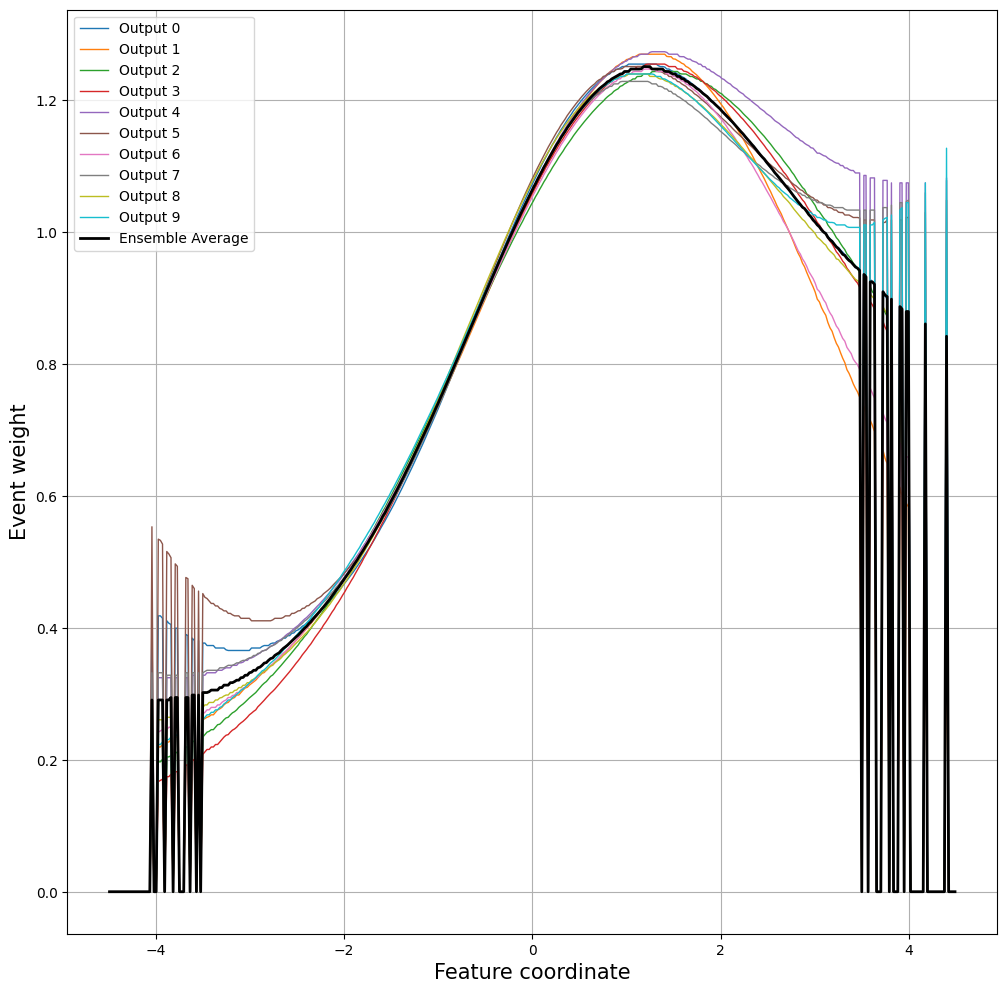

In [99]:
if ndim == 1 :
    hbins=400
    hpw,xe,ye = np.histogram2d( mc_pts[:,0], final_push_weights[:], bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
    ave_fpw, xvals = hist_to_func( hpw, xe, ye )
    ensemble_weight_functions = np.zeros( shape=(n_models_to_ensemble, hbins) )

    for ei in range( n_models_to_ensemble ) : 
        hpw,xe,ye = np.histogram2d( mc_pts[:,0], ensemble_final_push_weights[ei,:], 
                       bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
        ensemble_weight_functions[ei,:],_ = hist_to_func( hpw, xe, ye )
    

    fig,ax = plt.subplots( 1, 1, figsize=(12,12))
    ls = '-'
    msty = ''
    msz = 2
    lwd = 1
    
    for ef, function in enumerate(ensemble_weight_functions):
        ax.plot( xvals, function, label=f'Output {ef}',
                 linestyle=ls, marker=msty, markersize=msz, linewidth=lwd )
    ax.plot( xvals, ave_fpw, label='Ensemble Average',
             color='black', linestyle=ls, marker=msty, markersize=1.5*msz, linewidth=2*lwd )
    ax.set_xlabel('Feature coordinate', fontsize=15)
    ax.set_ylabel('Event weight', fontsize=15)
    ax.legend()
    plt.grid(True)
    plt.show()

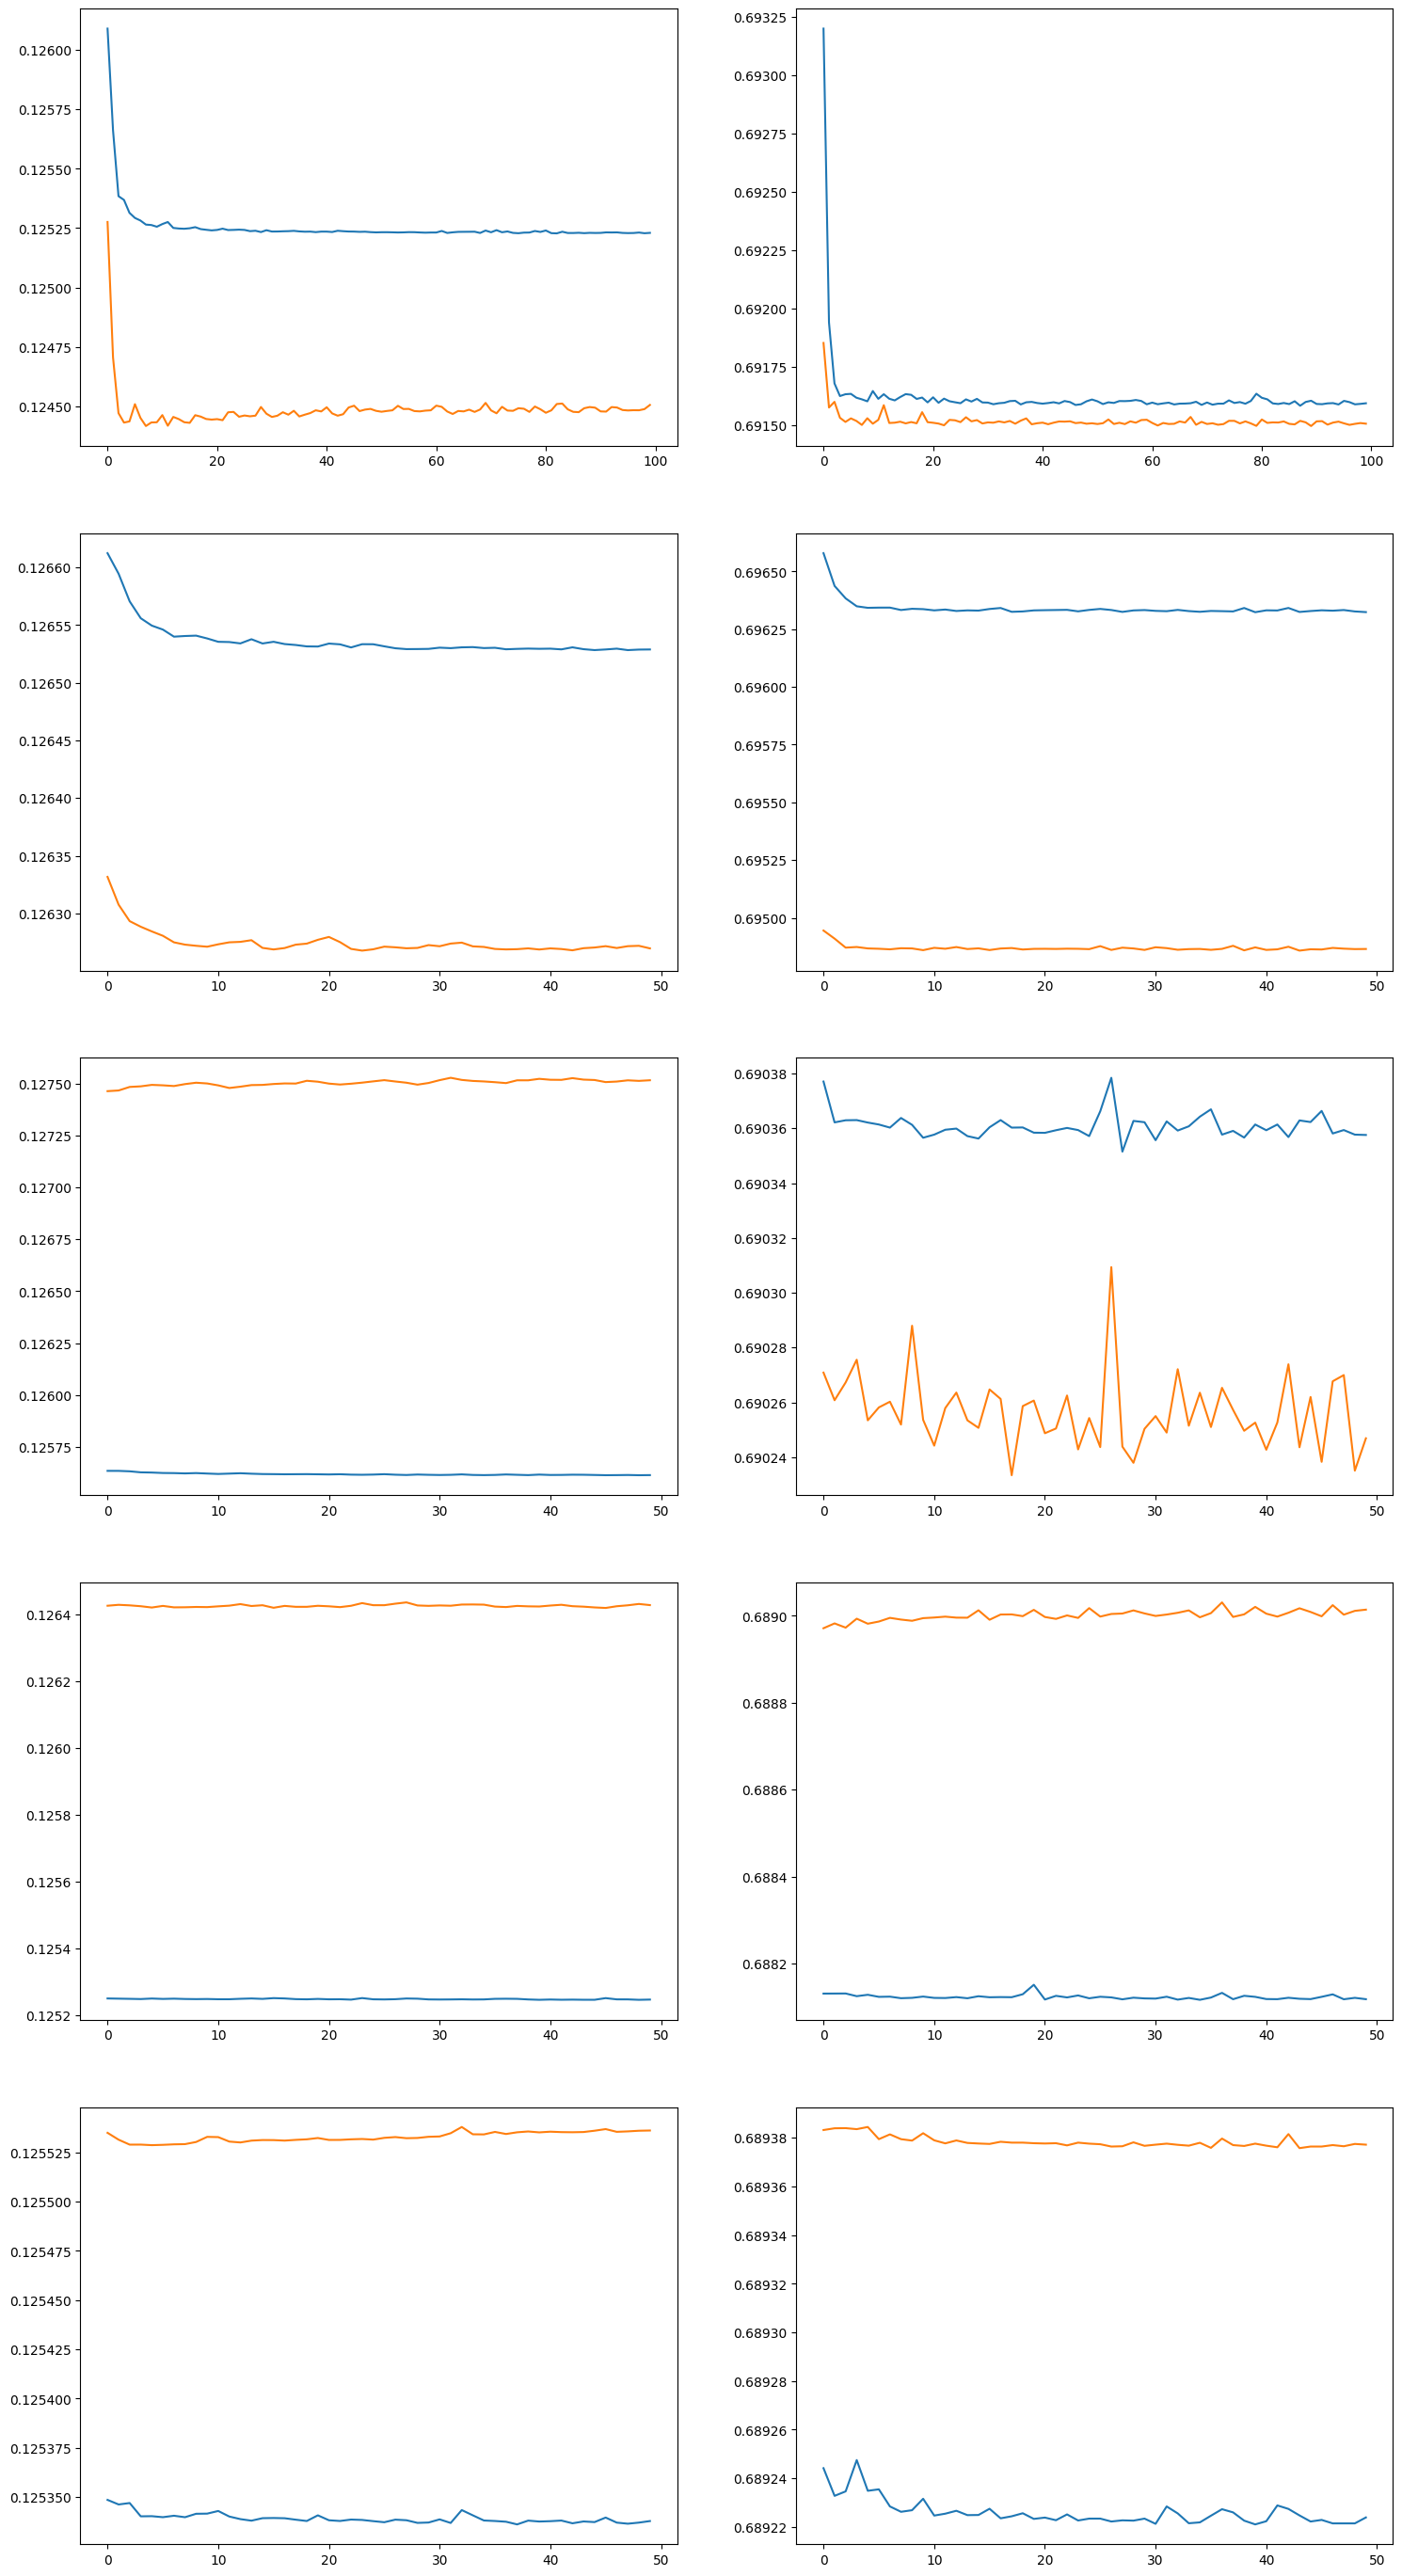

In [100]:
fig,ax = plt.subplots( of_niter, 2, figsize=(18,7*of_niter))
for ofi in range(of_niter) :
    ax[ofi][0].plot( of_return_dict[f'mc-hist-step1-iter{ofi}'].history['loss']  )
    ax[ofi][0].plot( of_return_dict[f'mc-hist-step1-iter{ofi}'].history['val_loss']  )

    ax[ofi][1].plot( of_return_dict[f'mc-hist-step2-iter{ofi}'].history['loss']  )
    ax[ofi][1].plot( of_return_dict[f'mc-hist-step2-iter{ofi}'].history['val_loss']  )  

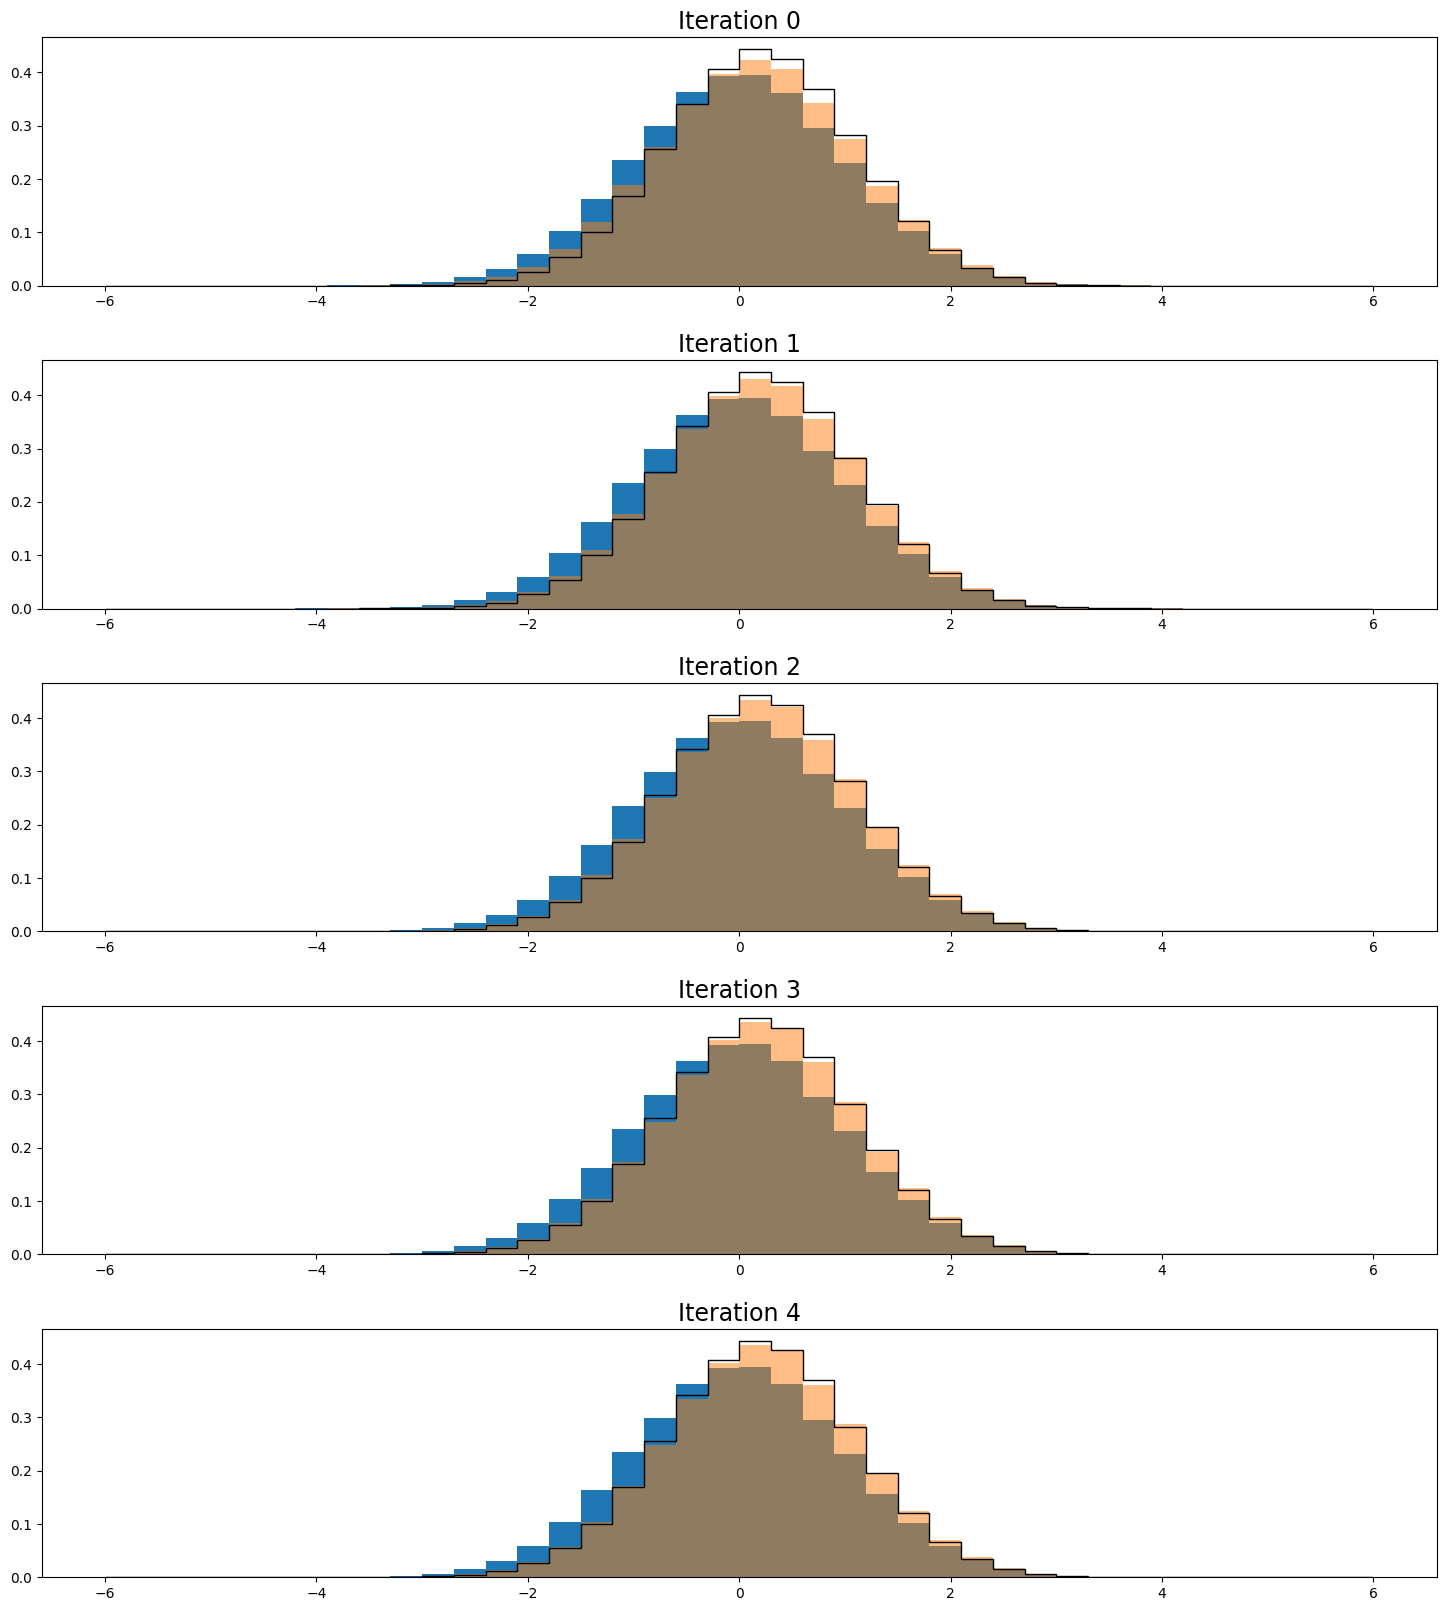

In [102]:
fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))

hmin=-6
hmax=6
hbins=40

hist_data_mc_ofweighted = np.empty( shape=(of_niter,ndim,hbins))
hist_data_truth         = np.empty( shape=(of_niter,ndim,hbins))

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

do_renorm = True

for ofi in range(of_niter):
    if do_renorm:
        for di in range(ndim):
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            thisax.hist(mc_pts[:,di],
                bins=hbins, density=True,
                range=[hmin,hmax],
                label='mc particle'
                )
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist(mc_pts[:,di],
                                                            weights=push_weights[ofi],
                                                            bins=hbins, density=True,
                                                            range=[hmin,hmax],
                                                            label='OF weighted particle',
                                                            alpha=0.5
                                                            )            
            hist_data_truth[ofi,di],_,_ = thisax.hist(
                true_pts10x[:,di],
                weights=true_pts10x_weights,
                bins=hbins, density=True,
                range=[hmin,hmax],
                label='true particle',
                histtype='step',
                color='black'
                )
    else :
        for di in range(ndim):
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]      
            hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist(mc_pts[:,di],
                weights=push_weights_scaled[ofi],
                bins=hbins,
                range=[hmin,hmax],
                label='OF weighted particle',
                alpha=0.5
                )            
            hist_data_truth[ofi,di],_,_ = thisax.hist(
                true_pts10x[:,di],
                weights=true_pts10x_weights,
                bins=hbins,
                range=[hmin,hmax],
                label='true particle',
                histtype='step',
                color='black'
                ) 
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]   
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )
plt.show()

In [103]:
hist_data_diff = hist_data_mc_ofweighted - hist_data_truth
hist_data_diff2 = hist_data_diff * hist_data_diff

hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        hist_data_sum_diff2[ofi,di] = np.sum( hist_data_diff2[ofi,di])

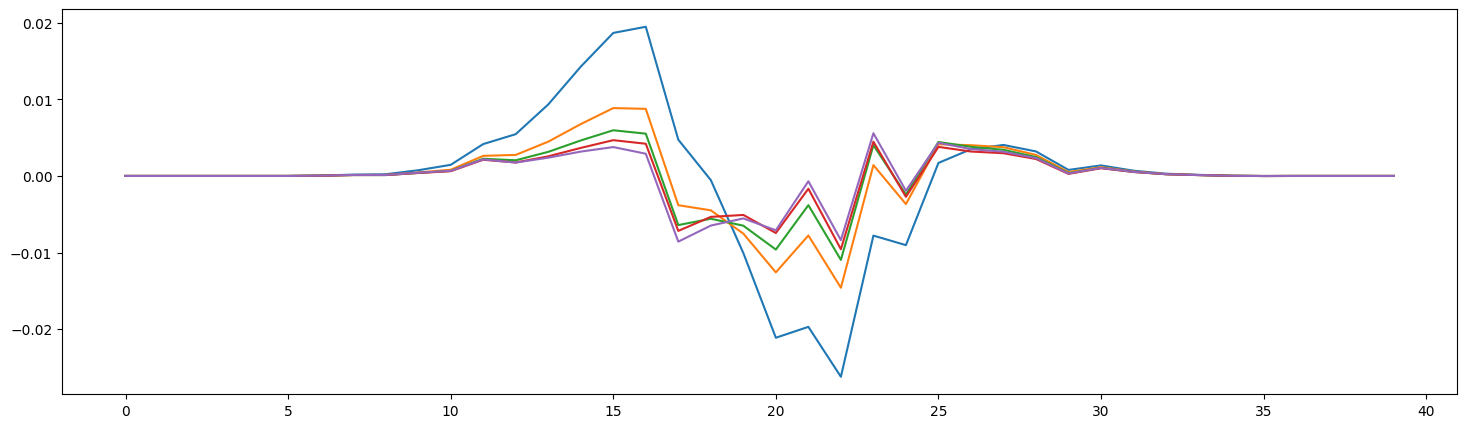

In [104]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim == 1 :
            axi = ax
        else :
            axi = ax[di]
        axi.plot(hist_data_diff[ofi,di])
plt.show()

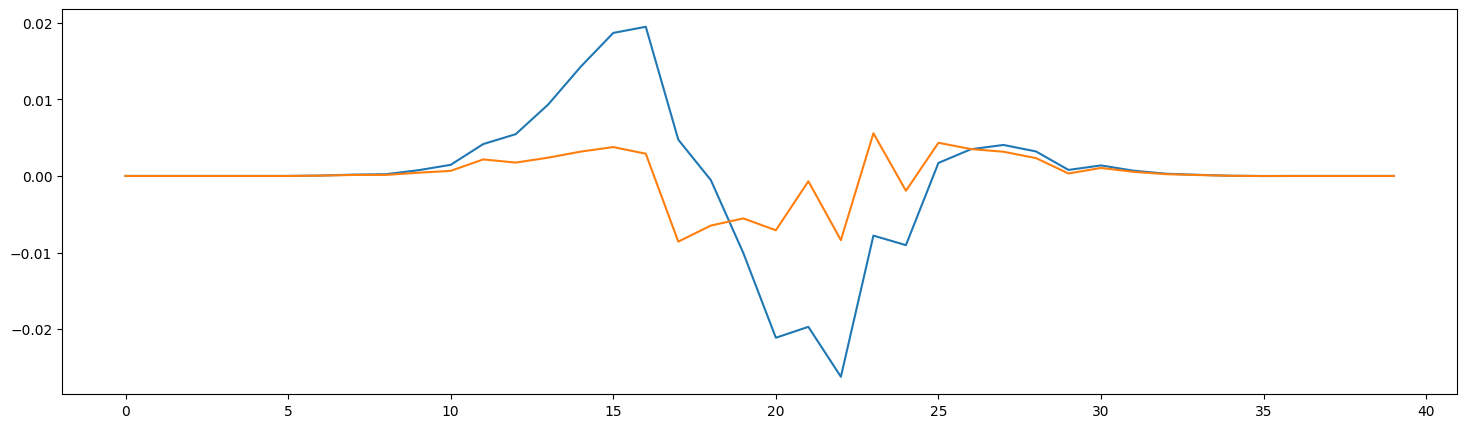

In [105]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))
ofi = 0
for di in range( ndim ) :
    if ndim == 1:
        axi = ax
    else:
        axi = ax[di]
    axi.plot(hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range(ndim):
    if ndim == 1:
        axi = ax
    else:
        axi = ax[di]
    axi.plot(hist_data_diff[ofi,di])
plt.show()

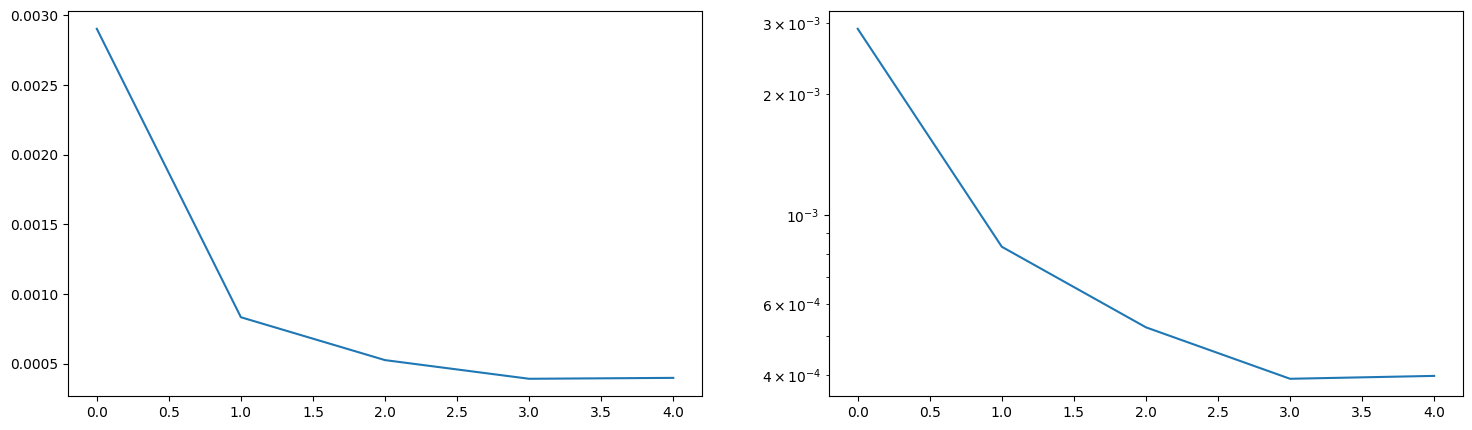

In [107]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( hist_data_sum_diff2)
ax[1].plot( hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show()

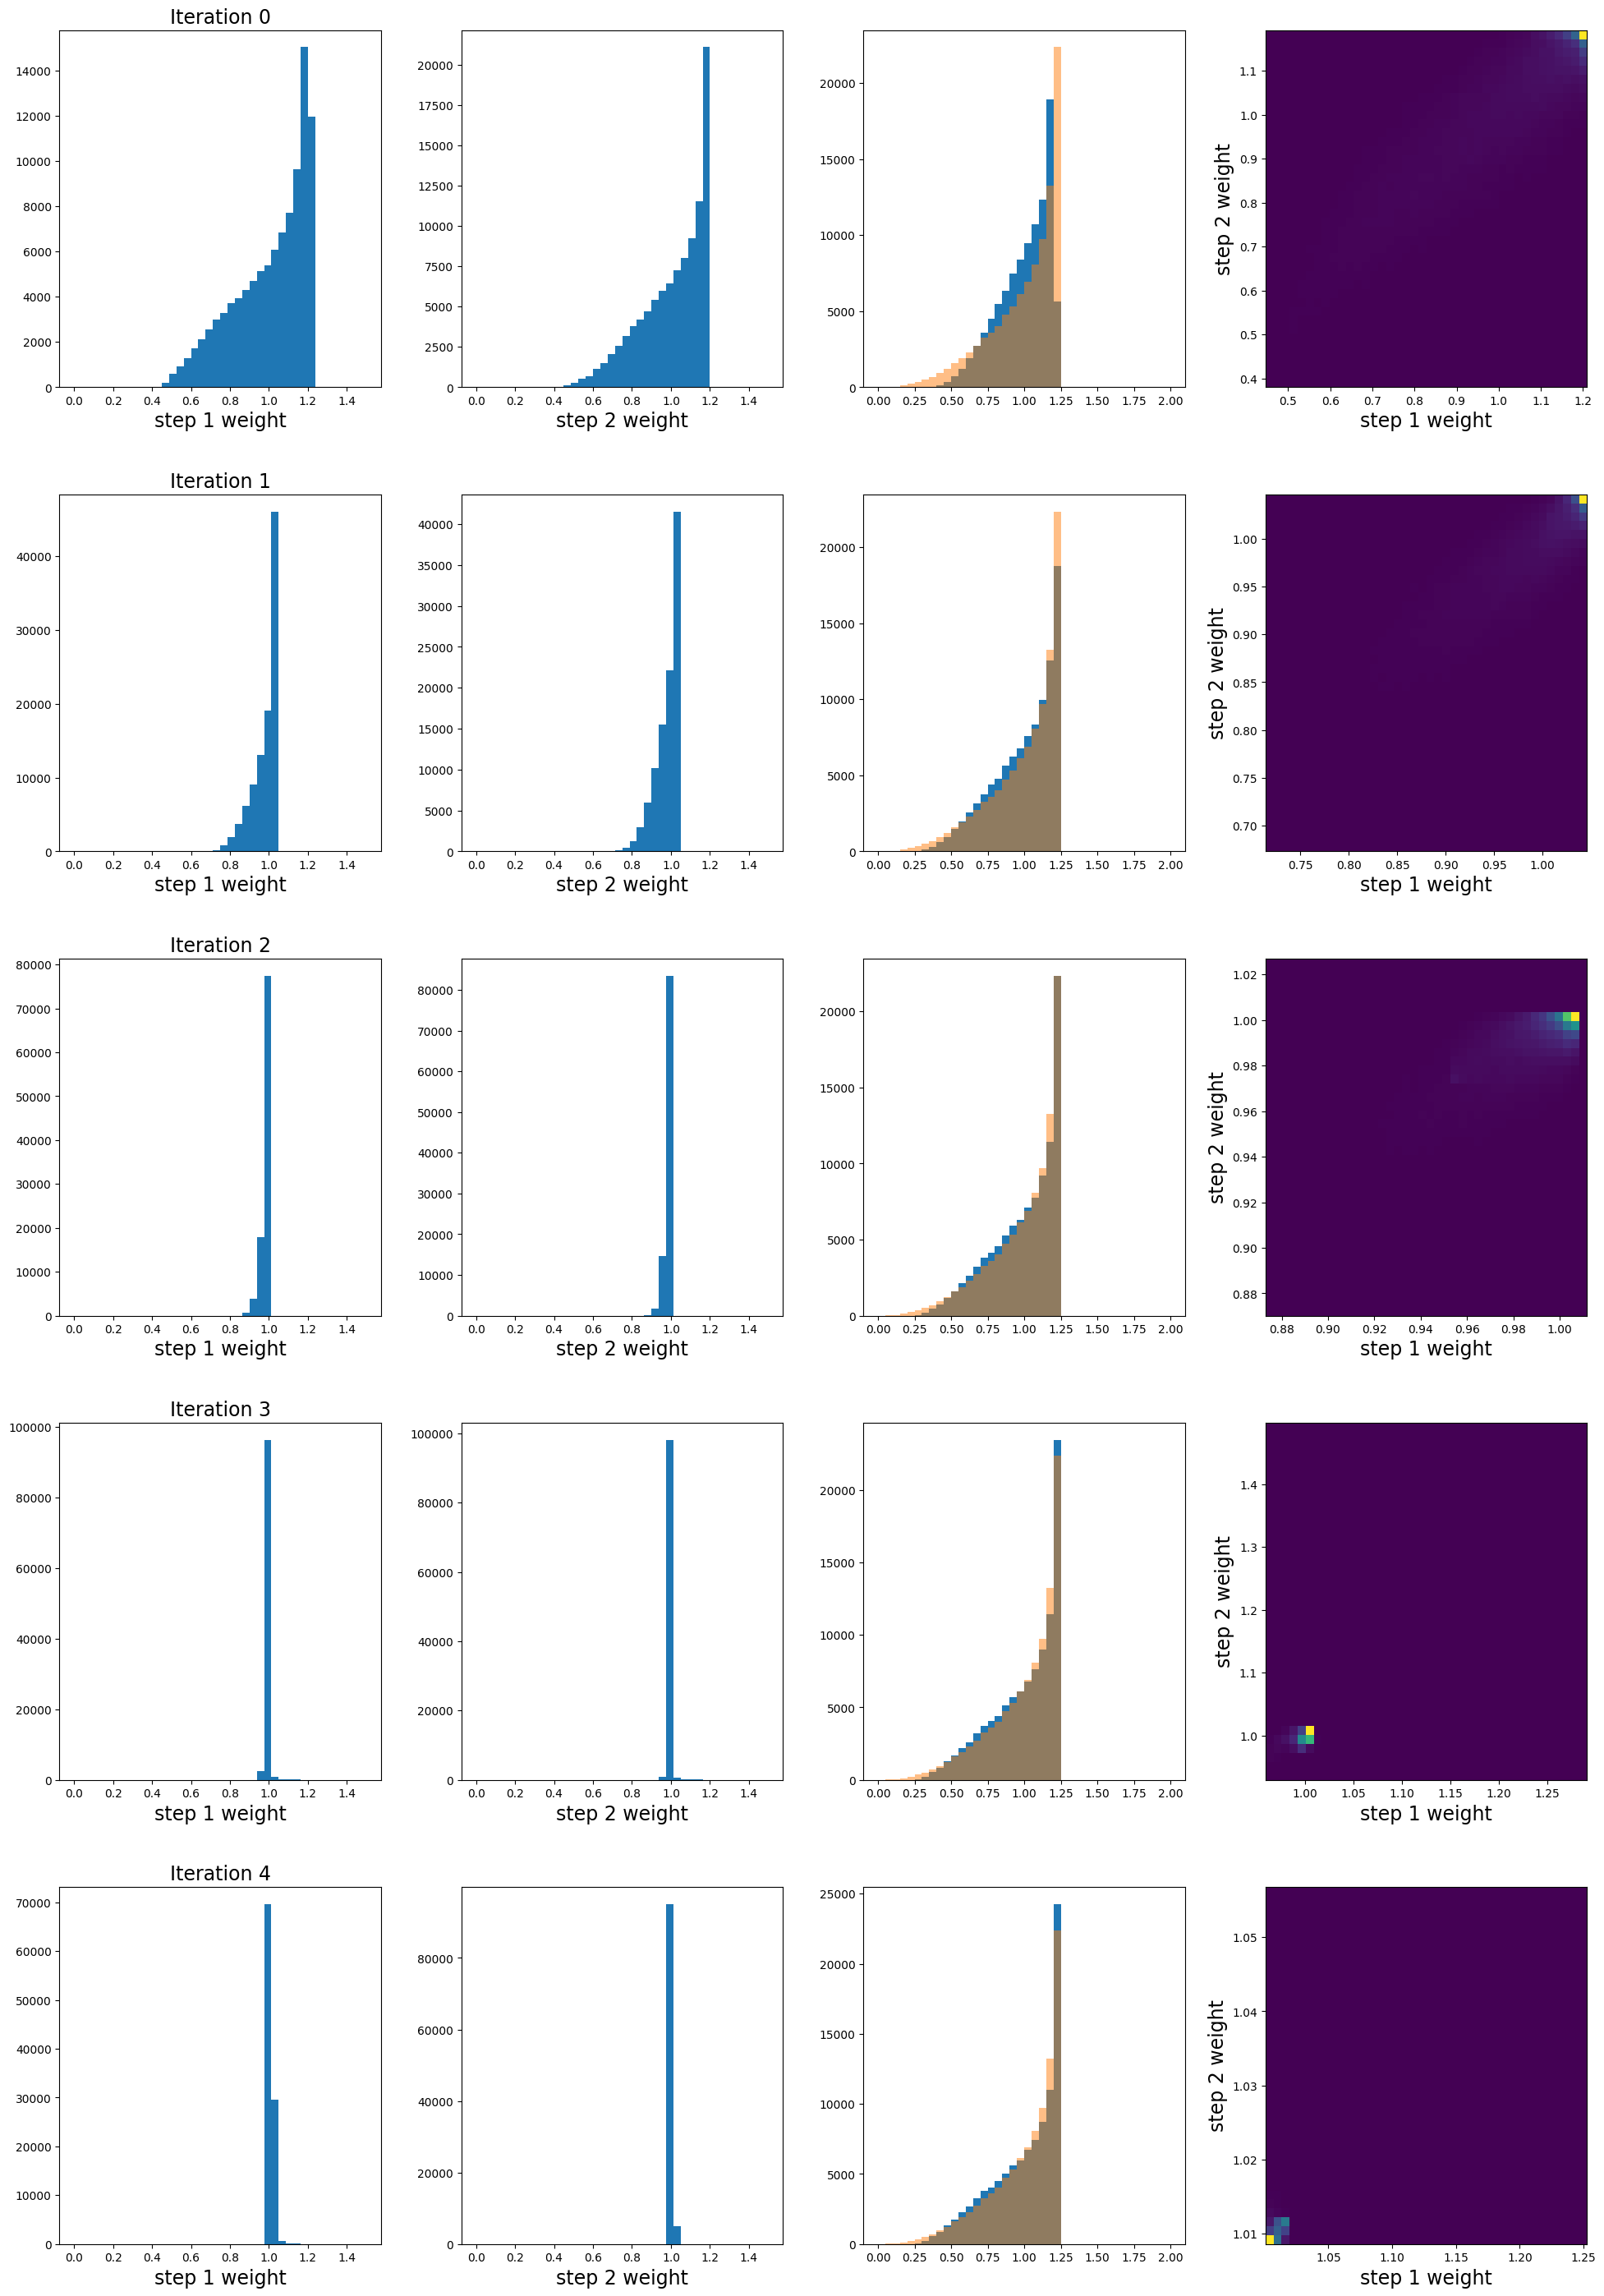

In [108]:
fig,ax = plt.subplots( of_niter, 4, figsize=(24,7*of_niter))

hmin=-6
hmax=6
hbins=40

lfontsize = 17

plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)

for ofi in range(0,of_niter):

    ax[ofi][0].hist(of_weights[ofi,0,:], bins=hbins, range=[0.,1.5] )
    ax[ofi][1].hist( of_weights[ofi,1,:], bins=hbins, range=[0.,1.5] )
    ax[ofi][2].hist( push_weights[ofi,:], bins=hbins, range=[0.,2.] )
    if ndim==1 :
        ax[ofi][2].hist( calc_weight, bins=hbins, range=[0.,2.0], alpha=0.5 )
    
    ax[ofi][3].hist2d( of_weights[ofi,0,:], of_weights[ofi,1,:], bins=[hbins,hbins] )
    ax[ofi][0].set_xlabel( 'step 1 weight', fontsize=lfontsize )
    ax[ofi][1].set_xlabel( 'step 2 weight', fontsize=lfontsize )
    ax[ofi][3].set_xlabel( 'step 1 weight', fontsize=lfontsize )
    ax[ofi][3].set_ylabel( 'step 2 weight', fontsize=lfontsize )
    ax[ofi][0].set_title('Iteration %d' % ofi, fontsize=lfontsize )
plt.show()

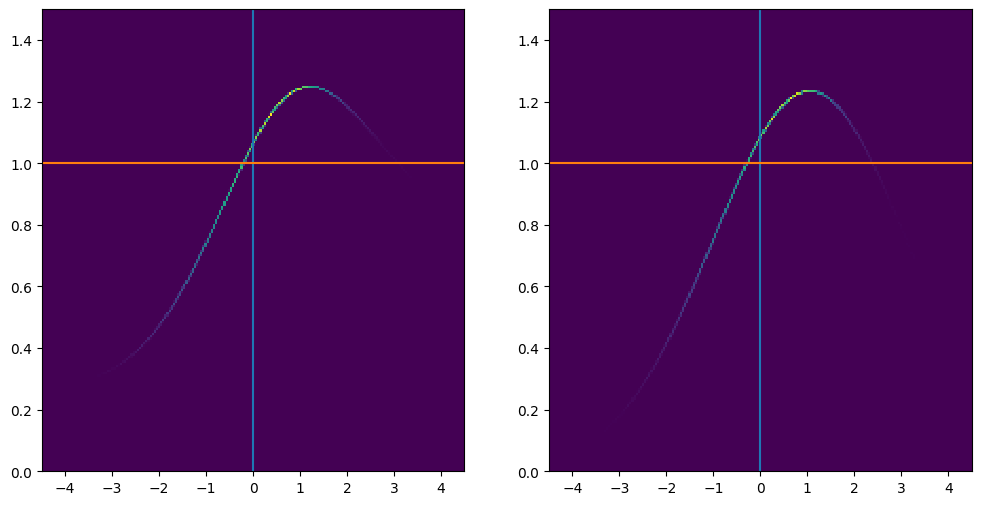

In [109]:
if ndim==1 :
    fig,ax = plt.subplots( 1, 2, figsize=(2*6,6))
    hbins=200
    hpw,xe,ye,_ = ax[0].hist2d( mc_pts[:,0], push_weights[-1,:], 
                          bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
    hcw,_,_,_ = ax[1].hist2d( mc_pts[:,0], calc_weight, 
                          bins=[hbins,hbins], range=([-4.5,4.5],[0.,1.5]) )
    ax[0].plot([0,0],[0,1.5])
    ax[0].plot([-4.5,4.5],[1,1])
    ax[1].plot([0,0],[0,1.5])
    ax[1].plot([-4.5,4.5],[1,1])
    plt.show()

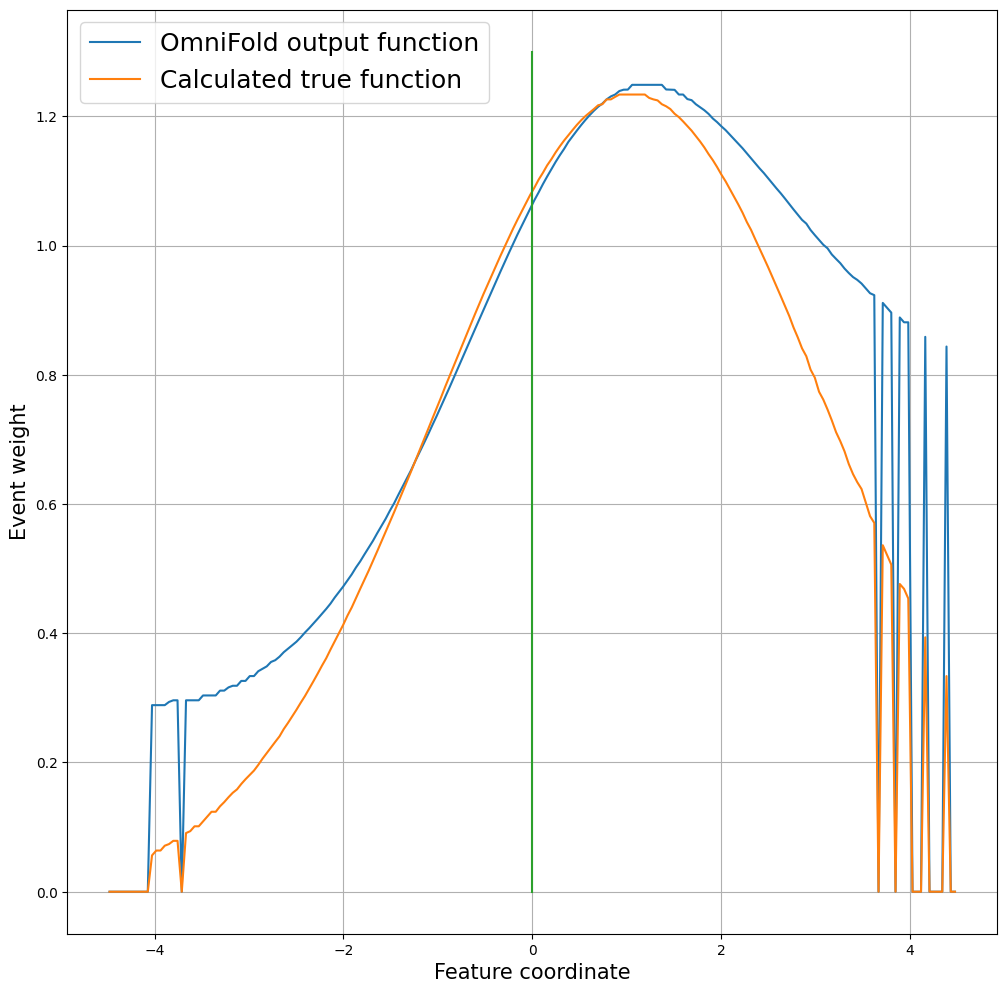

In [110]:
if ndim==1 :    
    ave_fpw, xvals = hist_to_func( hpw, xe, ye )
    calc_pw, xvals = hist_to_func( hcw, xe, ye )
    fig,ax = plt.subplots( 1, 1, figsize=(12,12))
    ax.plot(xvals, ave_fpw, label='OmniFold output function')
    ax.plot(xvals, calc_pw, label='Calculated true function')
    ax.plot([0,0],[0,1.3])
    ax.legend( fontsize=18 )
    ax.grid(True)
    ax.set_xlabel('Feature coordinate', fontsize=15)
    ax.set_ylabel('Event weight', fontsize=15)
    plt.show()    

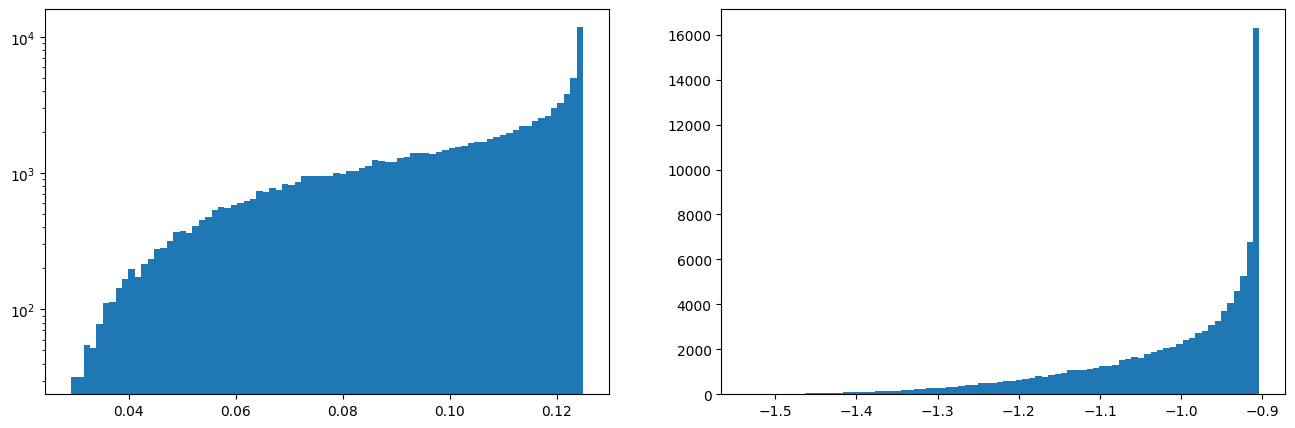

In [111]:
fig,ax = plt.subplots( 1, 2, figsize=(8*2,5))
hbins=80
ax[0].hist( final_push_weights_scaled, bins=hbins)
ax[0].set_yscale('log')
ax[1].hist( np.log10(final_push_weights_scaled), bins=hbins)
plt.show()

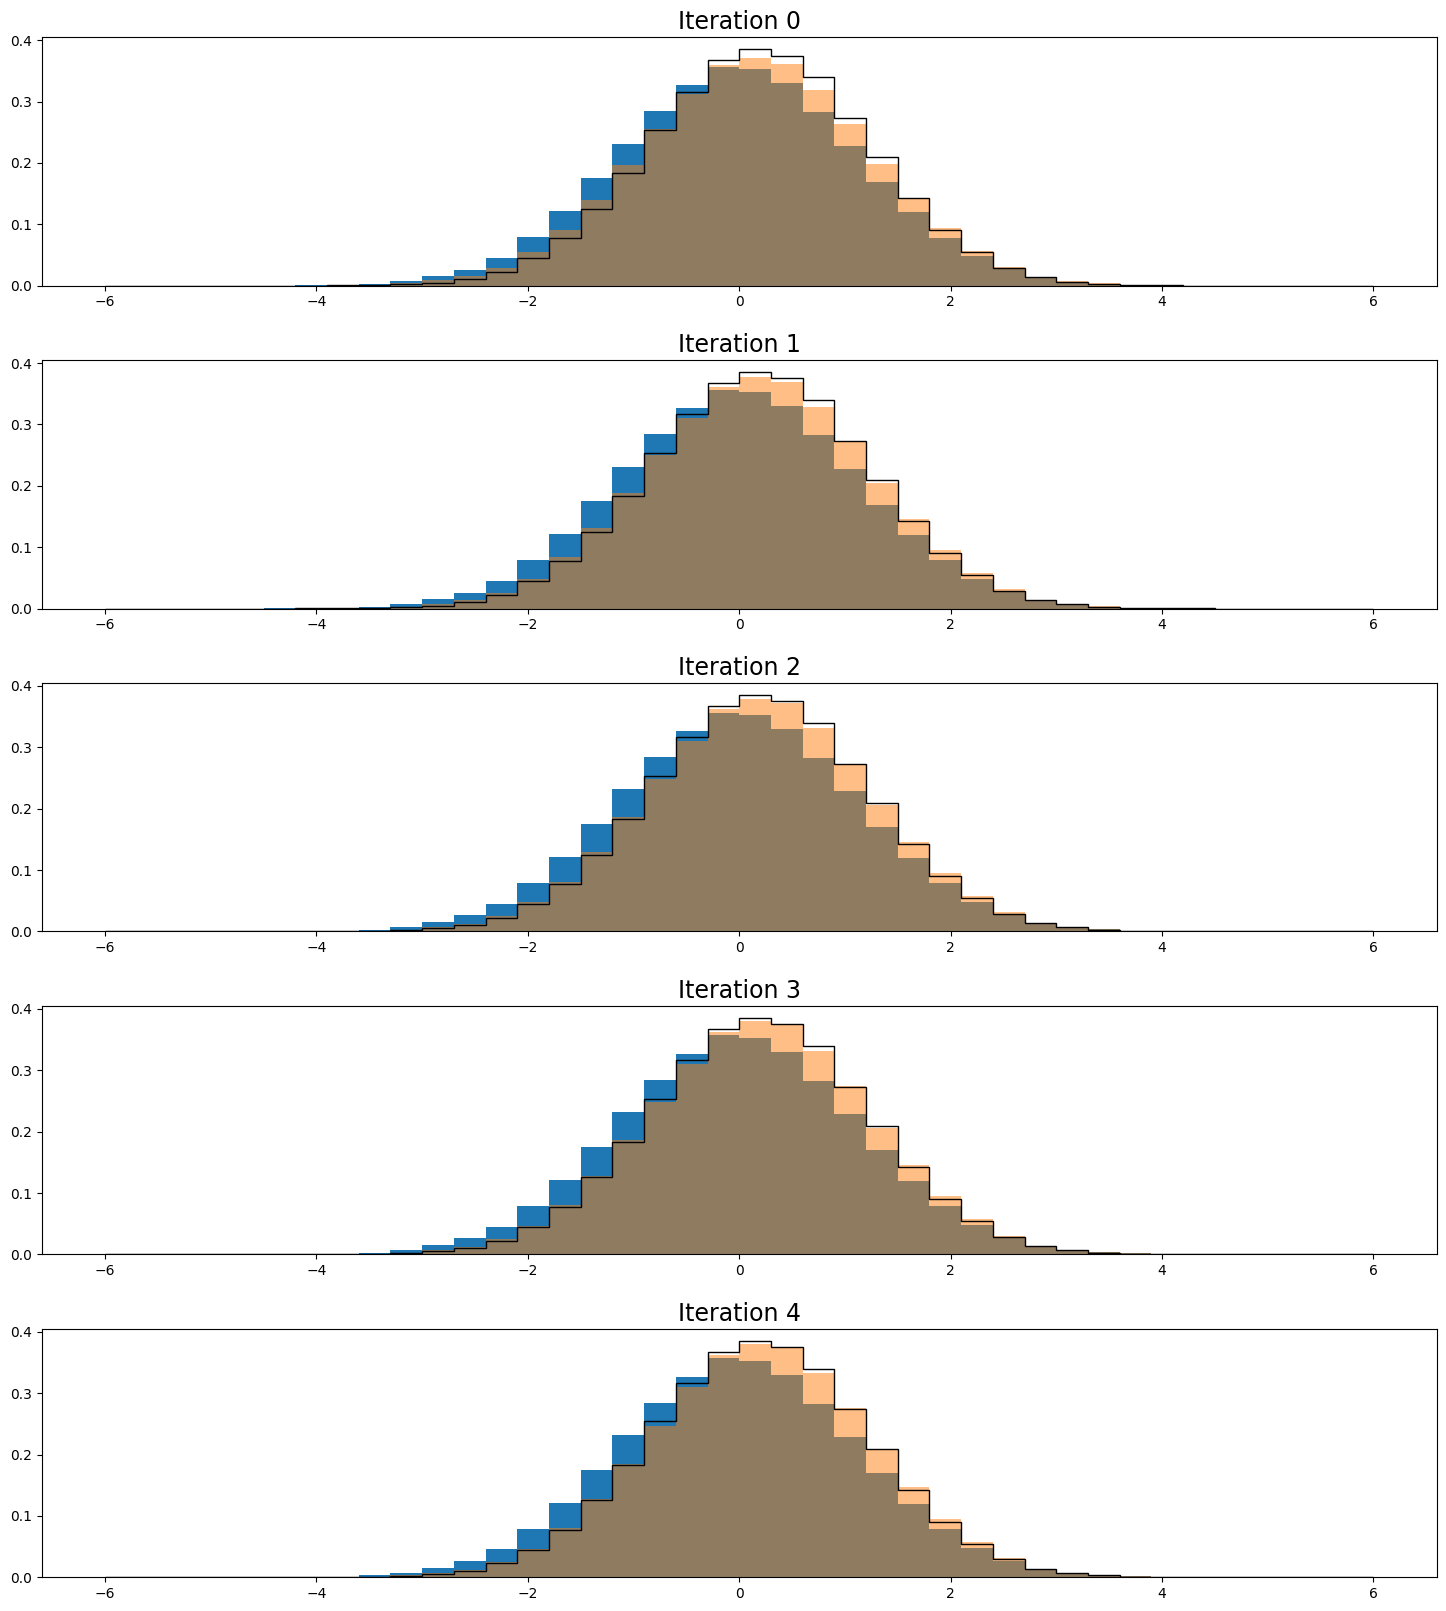

In [112]:
fig,ax = plt.subplots( of_niter, ndim, figsize=(18,4*of_niter))
hmin=-6
hmax=6
hbins=40

det_hist_data_mc_ofweighted = np.empty( shape=(of_niter,ndim,hbins))
det_hist_data_truth         = np.empty( shape=(of_niter,ndim,hbins))
lfontsize = 17
plt.subplots_adjust( hspace=0.30)
plt.subplots_adjust( wspace=0.25)
do_renorm = True
for ofi in range(of_niter) :
    if do_renorm :
        for di in range(ndim) :
            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
            thisax.hist(
                mc_det_pts[:,di],
                bins=hbins, density=True,
                range=[hmin,hmax],
                label='mc particle'
                )
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist(
                mc_det_pts[:,di],
                weights=push_weights[ofi],
                bins=hbins, density=True,
                range=[hmin,hmax],
                label='OF weighted particle',
                alpha=0.5
                )
            det_hist_data_truth[ofi,di],_,_ = thisax.hist(
                true_det_pts10x[:,di],
                weights=true_pts10x_weights,
                bins=hbins, density=True,
                range=[hmin,hmax],
                label='true particle',
                histtype='step',
                color='black'
                )
    else :
        
        for di in range(ndim) :

            if ndim > 1 :
                thisax = ax[ofi][di]
            else :
                thisax = ax[ofi]
        
            det_hist_data_mc_ofweighted[ofi,di],_,_ = thisax.hist( mc_det_pts[:,di],
                weights=push_weights_scaled[ofi],
                bins=hbins,
                range=[hmin,hmax],
                label='OF weighted particle',
                alpha=0.5
                )
            det_hist_data_truth[ofi,di],_,_ = thisax.hist(
                true_det_pts10x[:,di],
                weights=true_pts10x_weights,
                bins=hbins,
                range=[hmin,hmax],
                label='true particle',
                histtype='step',
                color='black' )
            
    if ndim > 1 :
        thisax = ax[ofi][0]
    else :
        thisax = ax[ofi]
    
    thisax.set_title('Iteration %d' % ofi, fontsize=lfontsize )
plt.show()

In [113]:
det_hist_data_diff = det_hist_data_mc_ofweighted - det_hist_data_truth
det_hist_data_diff2 = det_hist_data_diff * det_hist_data_diff

det_hist_data_sum_diff2 = np.zeros( shape=(of_niter,ndim))

for ofi in range( of_niter ) :
    for di in range( ndim ) :
        det_hist_data_sum_diff2[ofi,di] = np.sum( det_hist_data_diff2[ofi,di])


<function matplotlib.pyplot.show(close=None, block=None)>

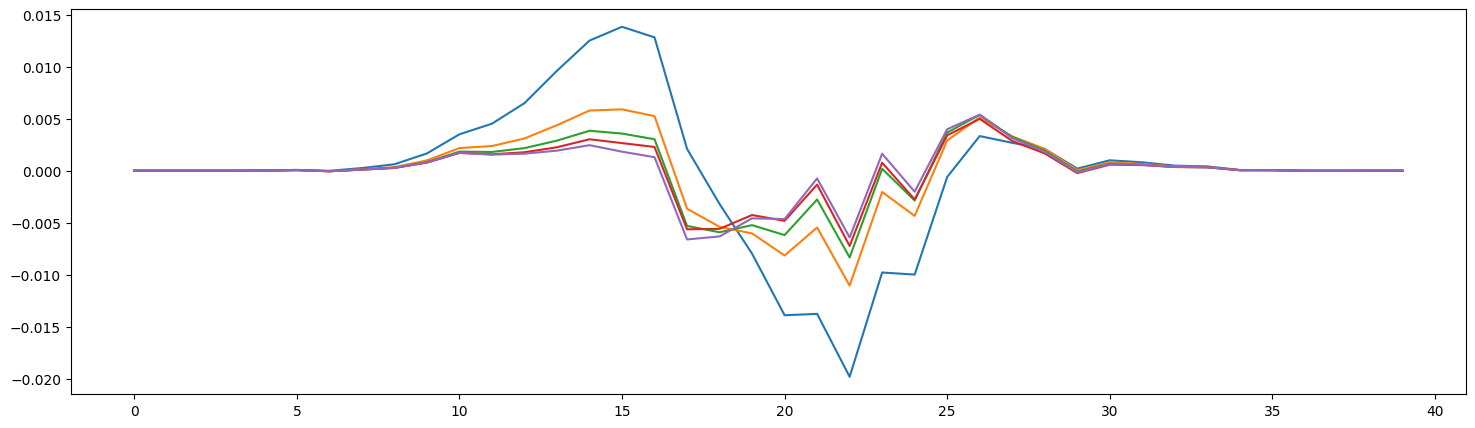

In [114]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

for ofi in range(of_niter) :
    for di in range( ndim ) :
        if ndim == 1 :
            axi = ax
        else :
            axi = ax[di]
        axi.plot(det_hist_data_diff[ofi,di])

    
plt.show   

<function matplotlib.pyplot.show(close=None, block=None)>

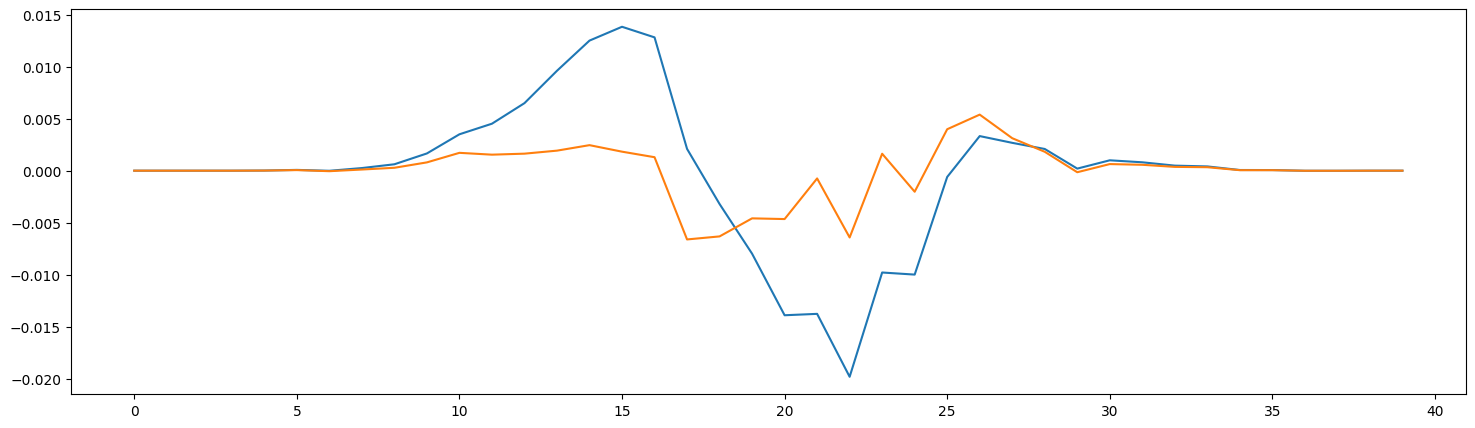

In [115]:
fig,ax = plt.subplots( 1, ndim, figsize=(18,5))

ofi = 0
for di in range( ndim ) :
    if ndim == 1 :
        axi = ax
    else :
        axi = ax[di]
    axi.plot(det_hist_data_diff[ofi,di])

ofi = of_niter-1
for di in range( ndim ) :
    if ndim == 1 :
        axi = ax
    else :
        axi = ax[di]
    axi.plot(det_hist_data_diff[ofi,di])

    
plt.show  

<function matplotlib.pyplot.show(close=None, block=None)>

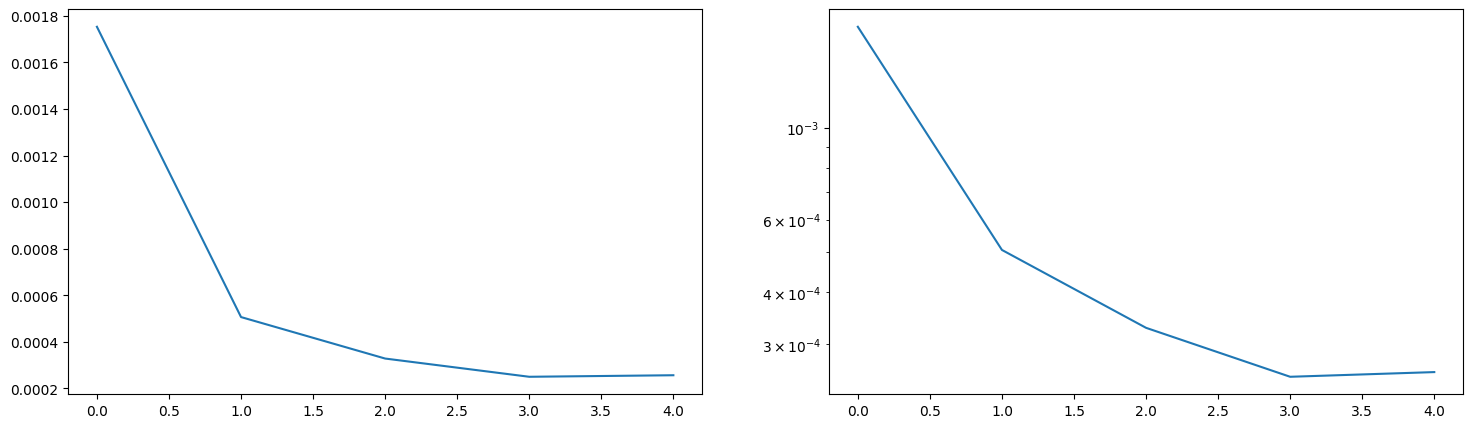

In [116]:
fig,ax = plt.subplots( 1, 2, figsize=(18,5))
ax[0].plot( det_hist_data_sum_diff2)
ax[1].plot( det_hist_data_sum_diff2)
ax[1].set_yscale('log')
plt.show

In [117]:
step1_mean = np.zeros( of_niter )
step1_rms = np.zeros( of_niter )

step2_mean = np.zeros( of_niter )
step2_rms = np.zeros( of_niter )

iter_val = np.zeros( of_niter )

for ofi in range( of_niter ) :
    
    iter_val[ofi] = ofi
    
    step1_mean[ofi] = np.mean( of_weights[ofi,0,:] )
    step1_rms[ofi] = np.sqrt( np.var( of_weights[ofi,0,:]))
    
    step2_mean[ofi] = np.mean( of_weights[ofi,1,:] )
    step2_rms[ofi] = np.sqrt( np.var( of_weights[ofi,1,:]))
    
    print("  iter %2d : step 1 mean  %.3f  rms %.3f      step 2 mean  %.3f  rms %.3f" % 
          (ofi, step1_mean[ofi], step1_rms[ofi], step2_mean[ofi], step2_rms[ofi]) )

  iter  0 : step 1 mean  1.006  rms 0.185      step 2 mean  1.008  rms 0.164
  iter  1 : step 1 mean  0.983  rms 0.065      step 2 mean  0.983  rms 0.059
  iter  2 : step 1 mean  0.987  rms 0.023      step 2 mean  0.988  rms 0.017
  iter  3 : step 1 mean  1.001  rms 0.011      step 2 mean  0.998  rms 0.010
  iter  4 : step 1 mean  1.009  rms 0.009      step 2 mean  1.010  rms 0.002


<function matplotlib.pyplot.show(close=None, block=None)>

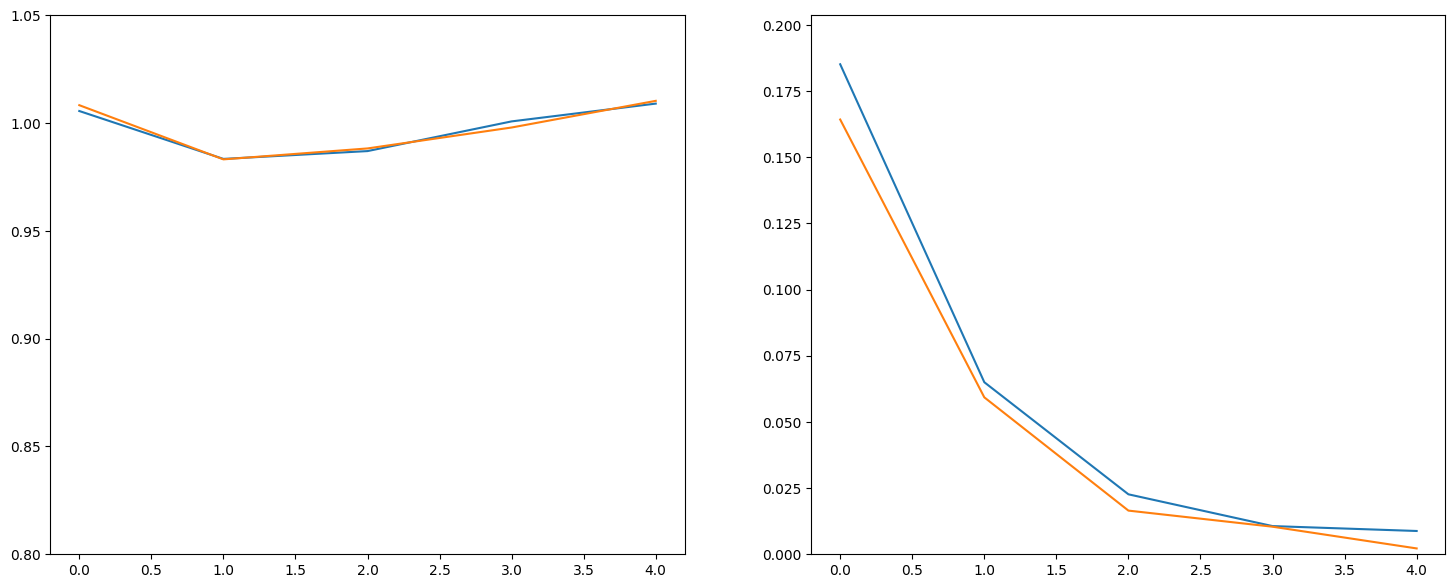

In [118]:
fig,ax = plt.subplots( 1, 2, figsize=(18,7))

ax[0].plot( iter_val, step1_mean )
ax[0].plot( iter_val, step2_mean )
ax[0].set_ylim( 0.80, 1.05)

ax[1].plot( iter_val, step1_rms )
ax[1].plot( iter_val, step2_rms )
ax[1].set_ylim( 0, 1.1*np.max(step1_rms))


plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

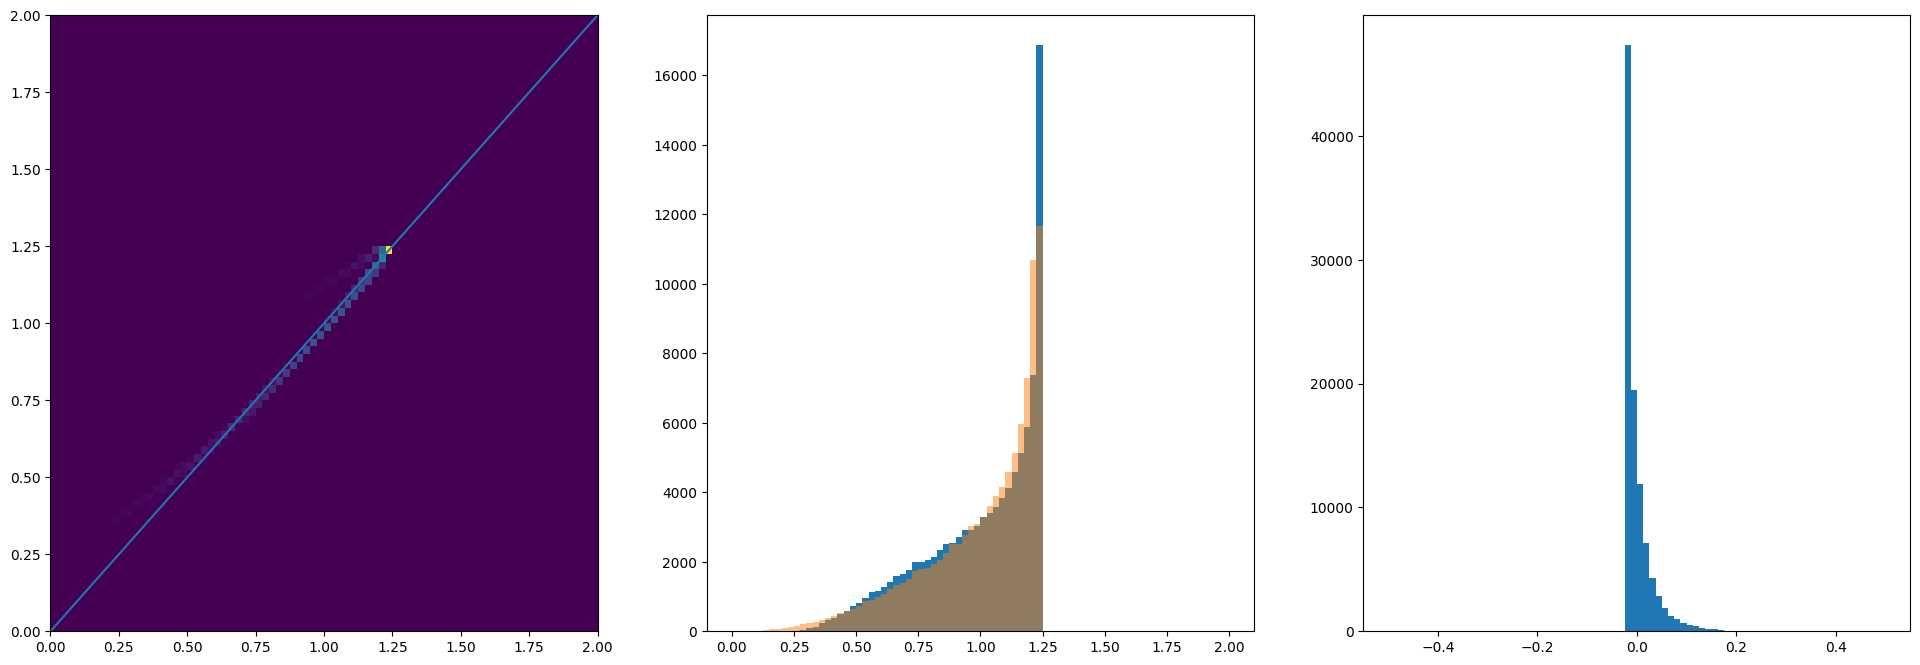

In [119]:
fig,ax = plt.subplots( 1, 3, figsize=(3*8,1*8))
max_weight = 2.0

ax[0].hist2d( calc_weight, final_push_weights, bins=[80,80], range=([0,max_weight],[0,max_weight]))
ax[0].plot([0,max_weight],[0,max_weight])

ax[1].hist( final_push_weights, bins=80, range=[0,max_weight] )
ax[1].hist( calc_weight, bins=80, range=[0,max_weight], alpha=0.5 )

ax[2].hist( final_push_weights-calc_weight, bins=80, range=[-0.5,0.5] )

plt.show

In [120]:
push_weights.shape

(5, 100000)

 Iteration 0:  delta weight  mean  -0.0002, RMS   0.0706
 Iteration 1:  delta weight  mean  -0.0035, RMS   0.0419
 Iteration 2:  delta weight  mean  -0.0010, RMS   0.0351
 Iteration 3:  delta weight  mean   0.0004, RMS   0.0310
 Iteration 4:  delta weight  mean  -0.0002, RMS   0.0327


<function matplotlib.pyplot.show(close=None, block=None)>

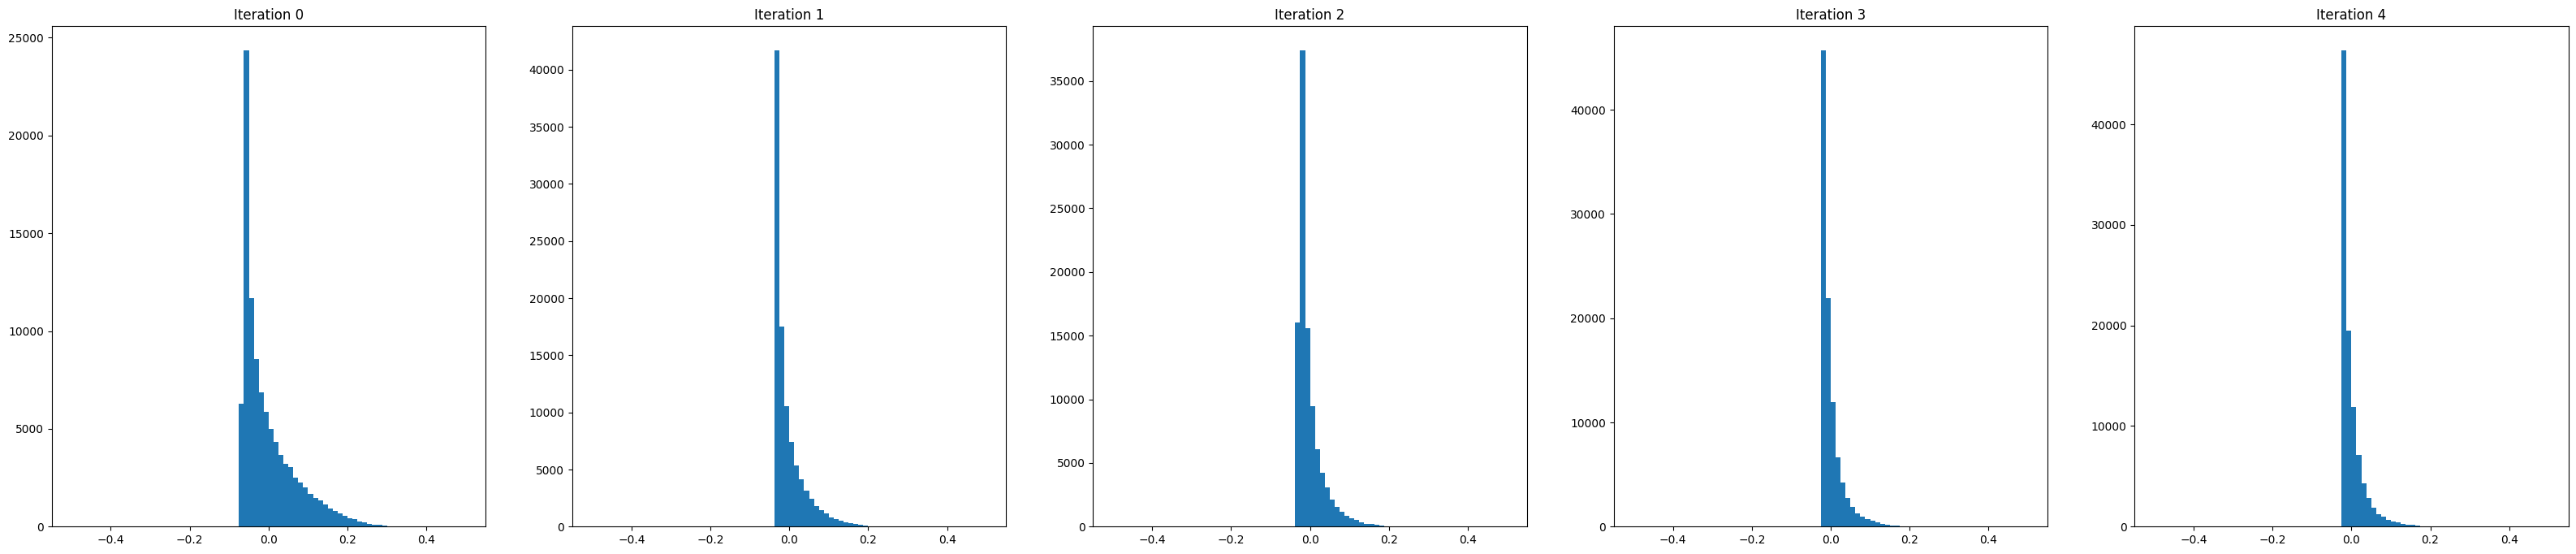

In [121]:
fig,ax = plt.subplots( 1, of_niter, figsize=(of_niter*8,1*8))

dw_mean = np.zeros( shape=(of_niter))
dw_rms = np.zeros( shape=(of_niter))

for i in range( of_niter ) :
    
    axi = ax[i]
    axi.hist( push_weights[i,:]-calc_weight, bins=80, range=[-0.5,0.5] )
    axi.set_title('Iteration %d' % i)
    
    dw_mean[i] = np.mean( push_weights[i,:]-calc_weight )
    dw_rms[i] = np.sqrt( np.cov(push_weights[i,:]-calc_weight))
    print(' Iteration %d:  delta weight  mean %8.4f, RMS %8.4f' % (i, dw_mean[i], dw_rms[i]))
    
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

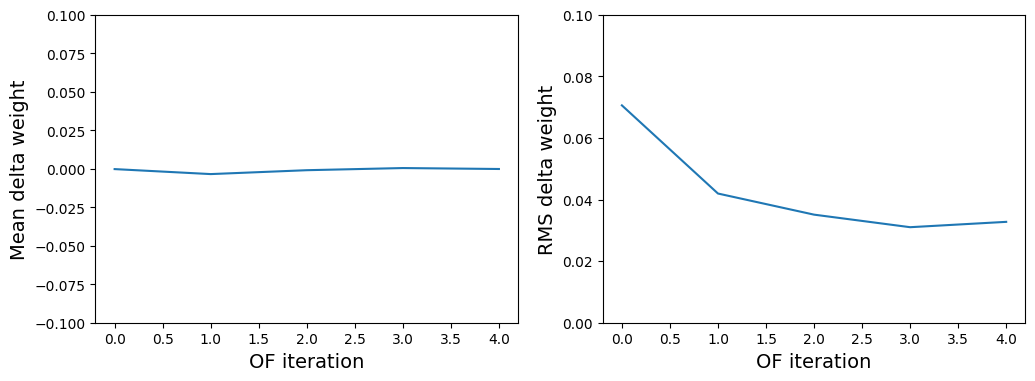

In [122]:
fig,ax = plt.subplots( 1, 2, figsize=(2*6,4))

axi=ax[0]
axi.plot( np.linspace(0,of_niter-1,of_niter), dw_mean )
axi.set_ylim([-0.1,0.1])
axi.set_xlabel('OF iteration', fontsize=14)
axi.set_ylabel('Mean delta weight', fontsize=14)

axi=ax[1]
axi.plot( np.linspace(0,of_niter-1,of_niter), dw_rms)
axi.set_ylim([0.0,0.1])
axi.set_xlabel('OF iteration', fontsize=14)
axi.set_ylabel('RMS delta weight', fontsize=14)


plt.show

In [133]:
def profile2d( axis, xvals, yvals, hbins, hrange, drawhist=True, drawline=False, drawcurve=True ) :
    
    hist_data = axis.hist2d( xvals, yvals, bins=hbins, range=hrange)
    
    if not drawhist :
        axis.cla()

    nybins = len(hist_data[0][0])
    #print("number of y bins: %d" % nybins)

    nxbins = len(hist_data[0])
    #print("number of x bins: %d" % nxbins)



    x_vals = np.zeros( nxbins )
    avey_vals = np.zeros( nxbins )
    rmsy_vals = np.zeros( nxbins )

    for xbi in range( nxbins ) :

        wsum = 0
        ywsum = 0
        yywsum = 0

        xval = 0.5 * ( hist_data[1][xbi] + hist_data[1][xbi+1] )
        #print(" xbin %d has center at %6.3f" % ( xbin_ind, xval ))

        for ybi in range( nybins ) :  
            yval = 0.5 * ( hist_data[2][ybi] + hist_data[2][ybi+1] )
            bin_content = hist_data[0][xbi][ybi]
            wsum = wsum + bin_content
            ywsum = ywsum + yval * bin_content
            yywsum = yywsum + yval * yval * bin_content
            #print("  %3d : y = %6.3f  bin content = %7d" % (bi, yval, bin_content))

        ave_y = ywsum / wsum
        ave_yy = yywsum / wsum
        rms_y = ave_yy - ave_y * ave_y
        #print(" Ave y = %.3f, RMS y = %.3f" % ( ave_y, rms_y) )

        x_vals[xbi] = xval
        avey_vals[xbi] = ave_y
        rmsy_vals[xbi] = rms_y


    #for xbi in range( nxbins ) :
        #print("  %4d :  x = %7.3f   ave y = %7.3f  rms y = %7.3f" % ( xbi, x_vals[xbi], avey_vals[xbi], rmsy_vals[xbi]))

    if drawline :
        axis.plot( (hist_data[1][0], hist_data[1][-1]), (0,0) )  
    
    if drawcurve :
        axis.errorbar( x_vals, avey_vals, yerr=np.abs(rmsy_vals), fmt='-', linewidth=5)

    
    plt.show
    
    return x_vals, avey_vals, rmsy_vals

In [134]:
ensemble_of_prob = of_return_dict['ensemble_weights'] / (1. + of_return_dict['ensemble_weights'])
ave_ensemble_of_prob = np.average( ensemble_of_prob, axis=0 )

In [135]:
ensemble_of_prob.shape

(10, 5, 2, 100000)

In [136]:
ensemble_of_prob[0,0,0,:]

array([0.512, 0.550, 0.533, ..., 0.396, 0.473, 0.544])

 OF iter 0, step 0 .

/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


.........
 OF iter 0, step 1 ..........
 OF iter 1, step 0 ..........
 OF iter 1, step 1 ..........
 OF iter 2, step 0 ..........
 OF iter 2, step 1 ..........
 OF iter 3, step 0 ..........
 OF iter 3, step 1 ..........
 OF iter 4, step 0 ..........
 OF iter 4, step 1 ..........


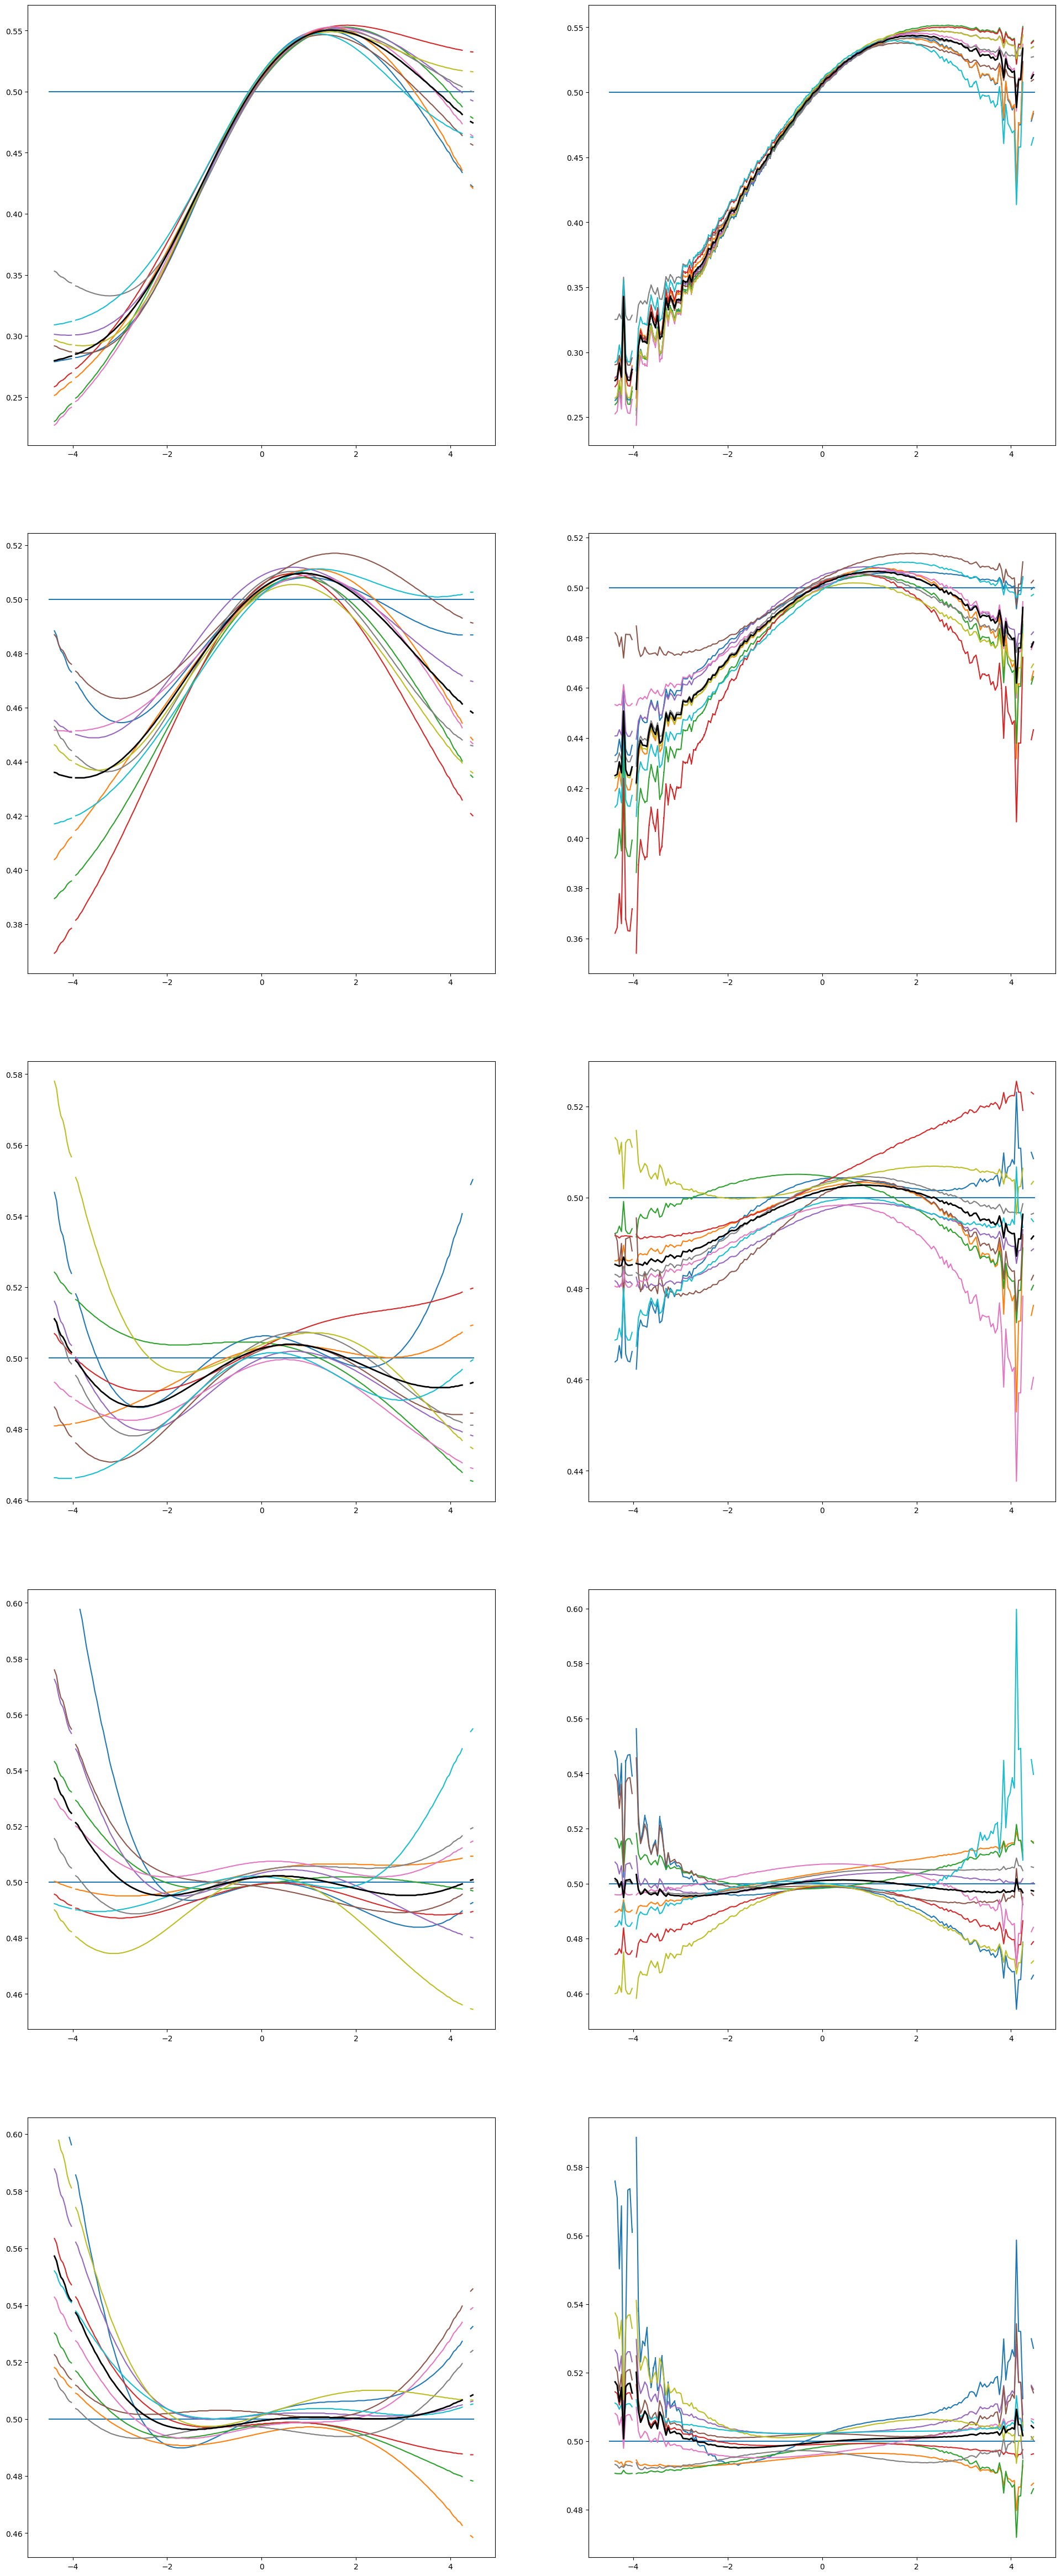

In [137]:
if ndim==1 :
    
    fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))

    xmin = -4.5
    xmax = 4.5

    ymin = 0.2
    ymax = 0.6

    x = np.zeros(shape=(n_models_to_ensemble,200))
    y = np.zeros(shape=(n_models_to_ensemble,200))
    e = np.zeros(shape=(n_models_to_ensemble,200))


    for ofi in range( of_niter ) :

        for si in range( 2 ) :

            print(' OF iter %d, step %d ' % (ofi,si), end='')

            axi = ax[ofi,si]

            for ei in range(n_models_to_ensemble) :
                print('.', end='')
                x[ei,:],y[ei,:],e[ei,:] = profile2d( axi, mc_det_pts[:,0], ensemble_of_prob[ei,ofi,si,:], 
                  hbins=[200,2000], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False, drawcurve=False ) 

            eax, eay, eae = profile2d( axi, mc_det_pts[:,0], ave_ensemble_of_prob[ofi,si,:], 
                  hbins=[200,2000], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False, drawcurve=False )


            for ei in range(n_models_to_ensemble) :
                axi.errorbar( x[ei,:], y[ei,:], np.abs(e[ei,:]) )

            axi.errorbar( eax, eay, np.abs(eae), color='black', linewidth=2 )

            axi.plot([xmin,xmax],[0.5,0.5])



            print()


    plt.show()


In [138]:
def prob_from_hists( points_a, points_b, weights_a, weights_b, hnbins, hxmin, hxmax ) :
    
    hbw = (hxmax-hxmin)/hnbins
    
    #-- calculate bin indices
    bin_indices_a = np.array( (points_a - hxmin)/hbw, dtype=int )
    bin_indices_b = np.array( (points_b - hxmin)/hbw, dtype=int )
    
    
    hist_binsum_a = np.zeros( hnbins )
    hist_binsum_b = np.zeros( hnbins )
    
    hist_err_a = np.zeros( hnbins )
    hist_err_b = np.zeros( hnbins )
    
    hist_ratio = np.zeros( hnbins )
    hist_ratio_err = np.zeros( hnbins )
    
    sample_wsum_a = np.sum(weights_a)
    sample_wsum_b = np.sum(weights_b)

    
    for bi in range( hnbins ) :
        hist_binsum_a[bi] = np.sum( weights_a[ bin_indices_a == bi ] ) / sample_wsum_a
        hist_binsum_b[bi] = np.sum( weights_b[ bin_indices_b == bi ] ) / sample_wsum_b
        hist_err_a[bi] = np.sqrt( np.sum( np.square( weights_a[ bin_indices_a == bi ] ) ) ) / sample_wsum_a
        hist_err_b[bi] = np.sqrt( np.sum( np.square( weights_b[ bin_indices_b == bi ] ) ) ) / sample_wsum_b
        if hist_binsum_b[bi] > 0 :
            hist_ratio[bi] = hist_binsum_b[bi] / (hist_binsum_a[bi] + hist_binsum_b[bi])
            if hist_binsum_a[bi] > 0 :
                hist_ratio_err[bi] = np.sqrt(
                    np.square( (hist_binsum_b[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_a[bi] ) +
                    np.square( (hist_binsum_a[bi]/np.square(hist_binsum_b[bi]+hist_binsum_a[bi])) * hist_err_b[bi] )
                )
        
    return_dict = {}
    return_dict['hist_binsum_a'] = hist_binsum_a
    return_dict['hist_binsum_b'] = hist_binsum_b
    return_dict['hist_err_a'] = hist_err_a
    return_dict['hist_err_b'] = hist_err_b
    return_dict['hist_ratio'] = hist_ratio
    return_dict['hist_ratio_err'] = hist_ratio_err
    
    return return_dict
    

## Examine the Likelihood Ratio output for Step 1 in OmniFold for each iteration

/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


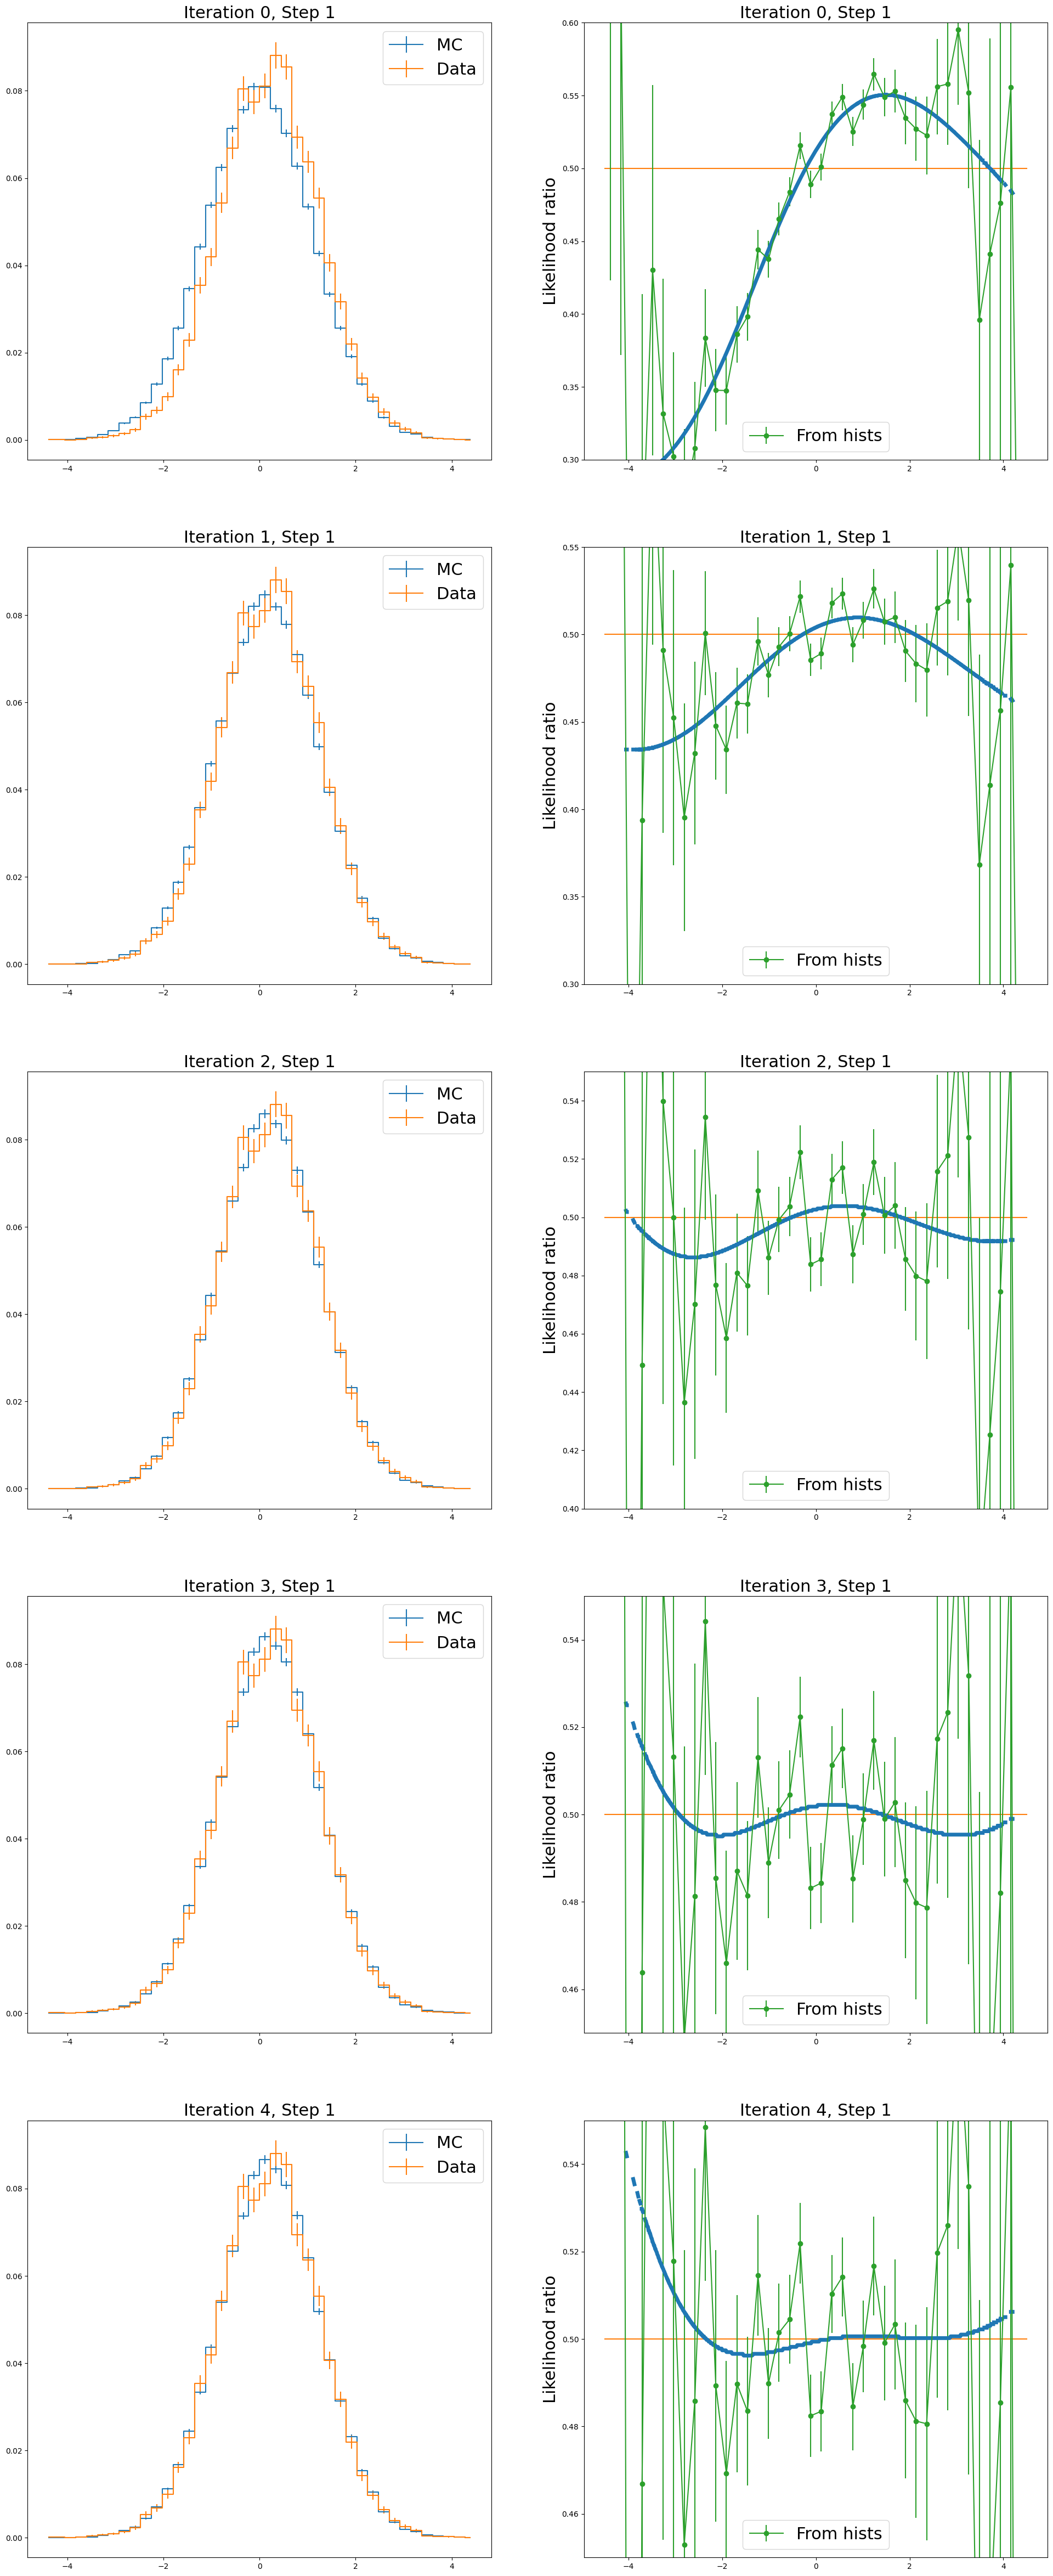

In [139]:

if ndim==1 :

    hxmin = -4.5
    hxmax = 4.5


    hnbins = 40



    hbw = (hxmax-hxmin) / hnbins

    xvals = np.zeros( hnbins )
    for bi in range( hnbins ) :
        xvals[bi] = hxmin + (0.5 + bi)*hbw

    nnbins = 1000

    plotymin=[0.30, 0.30, 0.40, 0.45, 0.45]
    plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]





    fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


    for ofi in range( of_niter ) :

        weights_ones_b = np.ones( len(true_det_pts[:,0]) )

        if ofi==0 :        
            weights_a = np.ones( len(mc_det_pts[:,0]) )        
        else :
            weights_a = of_return_dict['push_weights'][ofi-1]

        rd = prob_from_hists( mc_det_pts[:,0], 
                                 true_det_pts[:,0], 
                                 weights_a, 
                                 weights_ones_b, 
                                 hnbins, hxmin, hxmax )

        axi = ax[ofi][0]
        axi.errorbar( xvals, rd['hist_binsum_a'], np.abs(rd['hist_err_a']), drawstyle='steps-mid', label='MC')
        axi.errorbar( xvals, rd['hist_binsum_b'], np.abs(rd['hist_err_b']), drawstyle='steps-mid', label='Data')
        axi.legend( fontsize=22 )
        axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )

        axi = ax[ofi][1]
        profile2d( axi, mc_det_pts[:,0], ave_ensemble_of_prob[ofi,0,:], 
              hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
        axi.plot([hxmin,hxmax],[0.5,0.5])
        axi.errorbar(xvals,rd['hist_ratio'],np.abs(rd['hist_ratio_err']), marker='o', linestyle='-', label='From hists')
        axi.legend( fontsize=22 )
        axi.set_ylabel('Likelihood ratio', fontsize=22 )

        axi.set_ylim( plotymin[ofi], plotymax[ofi] )
        axi.set_title('Iteration %d, Step 1' % ofi, fontsize=22 )




    plt.show()

/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/var/folders/23/v_qmt2w51gq3snvmr302vvzr0000gp/T/ipykernel_2886/658999686.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


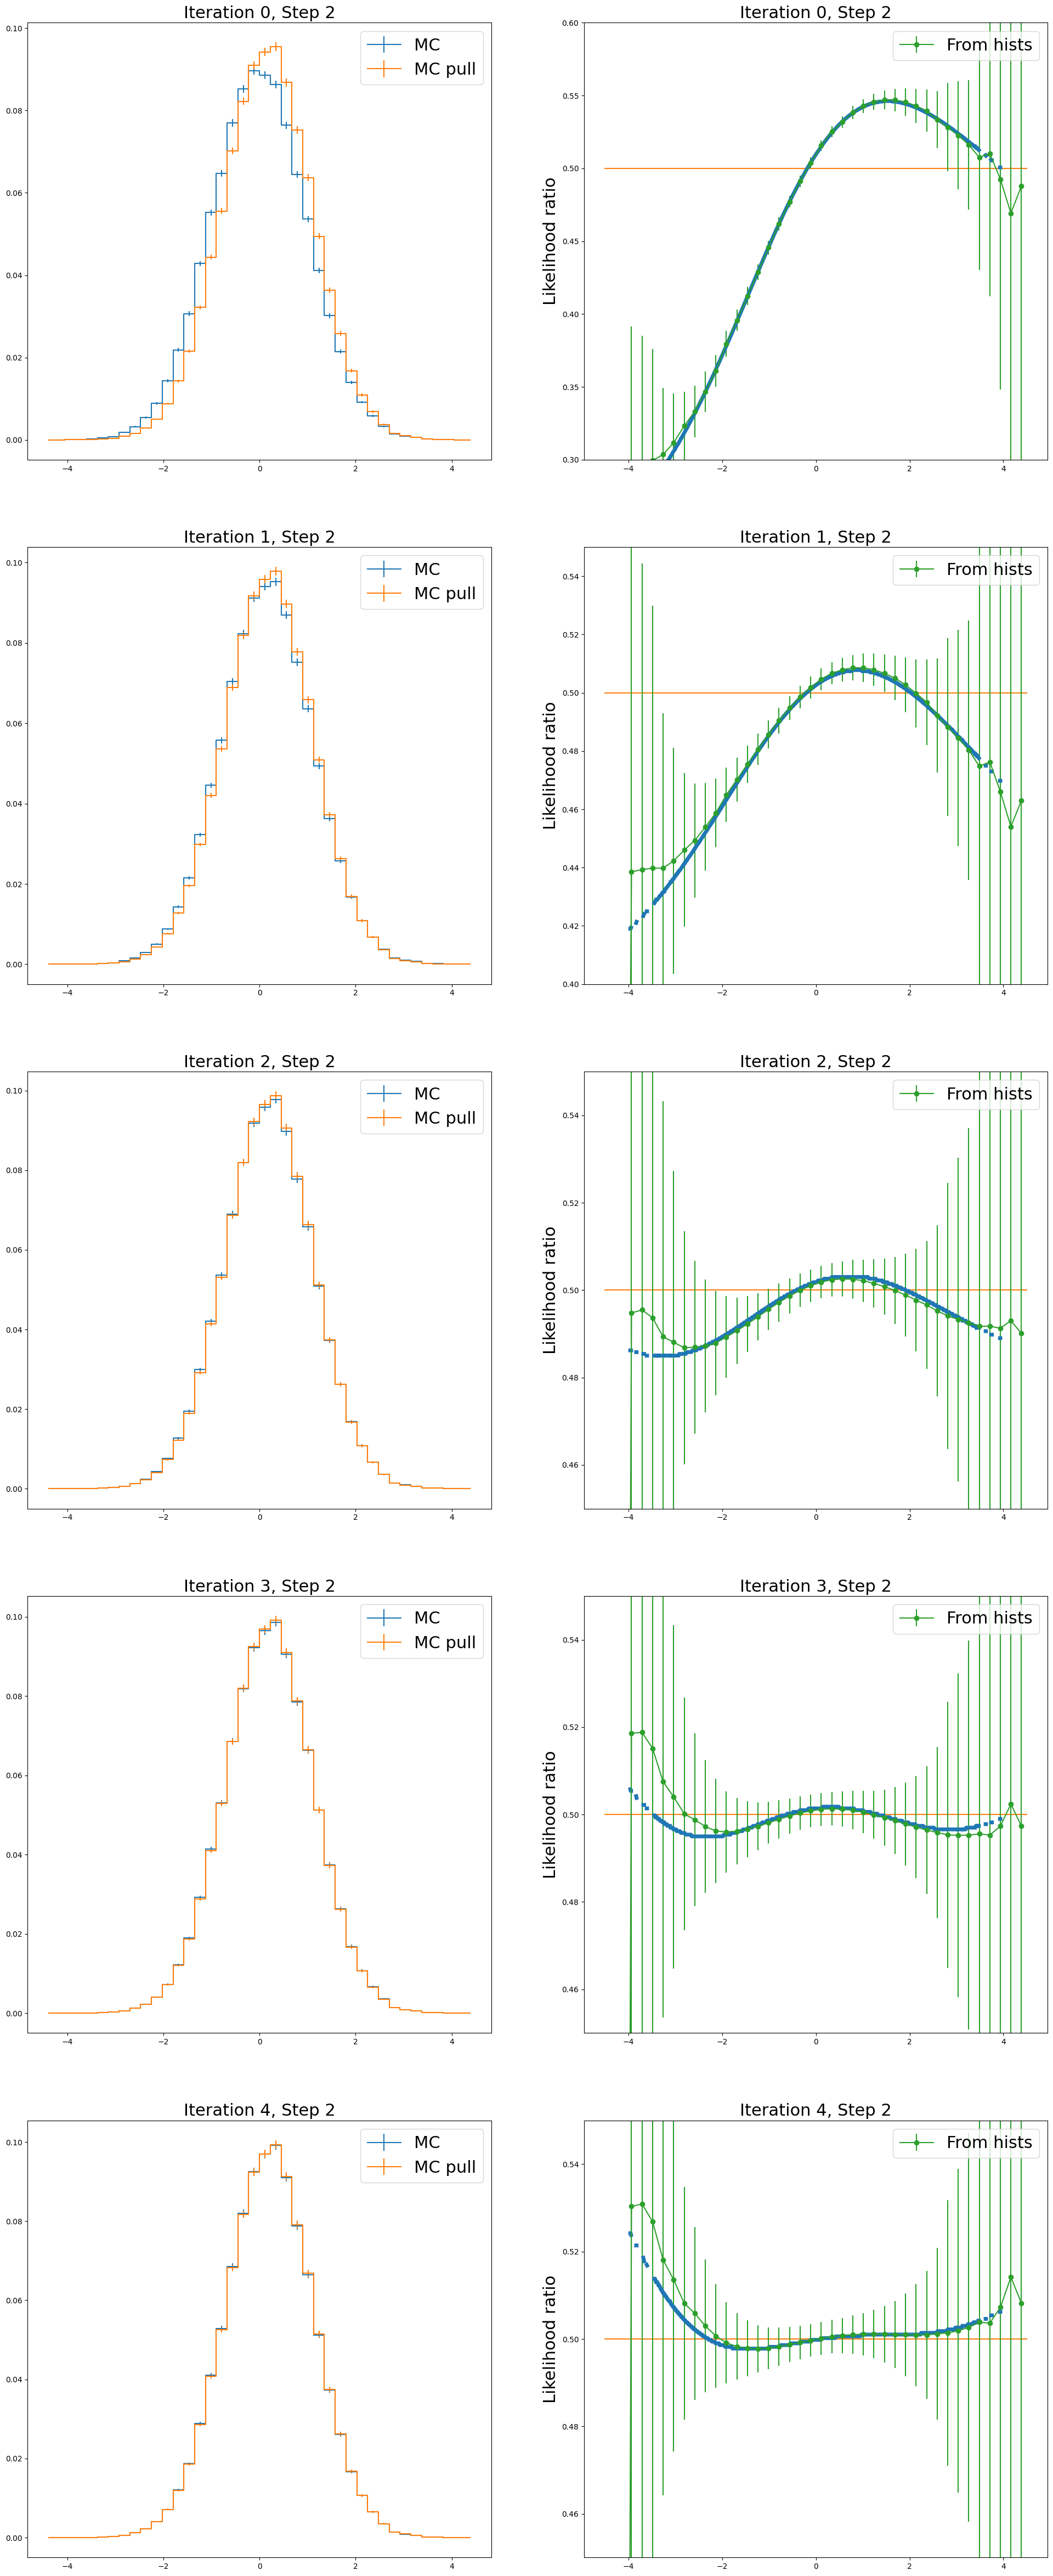

In [140]:

if ndim==1 :

    hxmin = -4.5
    hxmax = 4.5


    hnbins = 40



    hbw = (hxmax-hxmin) / hnbins

    xvals = np.zeros( hnbins )
    for bi in range( hnbins ) :
        xvals[bi] = hxmin + (0.5 + bi)*hbw

    nnbins = 1000

    plotymin=[0.30, 0.40, 0.45, 0.45, 0.45]
    plotymax=[0.60, 0.55, 0.55, 0.55, 0.55]






    fig,ax = plt.subplots( of_niter, 2, figsize=(2*12,of_niter*12))


    for ofi in range( of_niter ) :

        previous_push_weights = np.ones( len(mc_pts[:,0]))
        if ofi > 0 :
            previous_push_weights = of_return_dict['push_weights'][ofi-1]

        #pull_weights = previous_push_weights * of_return_dict['weights'][ofi,0,:]



        rd = prob_from_hists( mc_pts[:,0], 
                                 mc_pts[:,0], 
                                 previous_push_weights, 
                                 pull_weights[ofi], 
                                 hnbins, hxmin, hxmax )

        axi = ax[ofi][0]
        axi.errorbar( xvals, rd['hist_binsum_a'], rd['hist_err_a'], drawstyle='steps-mid', label='MC')
        axi.errorbar( xvals, rd['hist_binsum_b'], rd['hist_err_b'], drawstyle='steps-mid', label='MC pull')
        axi.legend( fontsize=22 )
        axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )

        axi = ax[ofi][1]
        profile2d( axi, mc_pts[:,0], ave_ensemble_of_prob[ofi,1,:], 
              hbins=[nnbins,nnbins], hrange=([xmin,xmax],[ymin,ymax]), drawhist=False, drawline=False ) 
        axi.plot([hxmin,hxmax],[0.5,0.5])
        axi.errorbar(xvals,rd['hist_ratio'],rd['hist_ratio_err'], marker='o', linestyle='-', label='From hists')
        axi.legend( fontsize=22 )
        axi.set_ylabel('Likelihood ratio', fontsize=22 )

        axi.set_ylim( plotymin[ofi], plotymax[ofi] )
        axi.set_title('Iteration %d, Step 2' % ofi, fontsize=22 )




    plt.show

# Bootstrap / Toy MC below here

In [ ]:
verbose = False

In [142]:
try:
    os.mkdir( "%s/bootstrap-nn-models" % output_dir )
except :
    print('problem creating bootstrap-nn-models dir')


In [143]:
%%time

for bi in range(0,n_boot_samples) :
    
    this_random_seed = random_seed*10000+bi
    
    np.random.seed( this_random_seed )
    keras.utils.set_random_seed( this_random_seed )

    
    if do_bootstrap :
        print("\n\n\n\n ============= Creating bootstrap sample %3d,  seed %d" % (bi, this_random_seed) )
        boot_true_det_pts = rng.choice( true_det_pts, size=len(true_det_pts) )
        
    else :
        this_ngen_true = ngen_true
        if use_poisson_fluctuations_around_ngen_true : this_ngen_true = np.random.poisson( ngen_true )
        print("\n\n\n\n\n ======================= Creating toy sample %3d,  this_ngen_true = %d, seed %d" % 
              (bi, this_ngen_true, this_random_seed) )
        boot_true_pts = np.random.multivariate_normal(true_mu, true_cov, size=this_ngen_true)
        boot_true_det_pts = np.random.normal( boot_true_pts, resolution )
        
    modeldir = "%s/bootstrap-nn-models/bs-%03d" % (output_dir, bi) 
    
    try:
        os.mkdir( modeldir )
    except :
        print('\n\n *** probelm creating model output directory : %s' % modeldir )

        
  
        
    boot_of_return_dict = omnifold( 
        mc_both, boot_true_det_pts, of_niter, model_step1, model_step2, verbose, 
        batch_size_setval, epochs_setval, 
        save_step2_model, modeldir, patience_setval, restore_best_weights_setval )



    mc_weight_sf = (1.*len(boot_true_det_pts))/(1.*len(mc_both))



    boot_final_push_weights = boot_of_return_dict["final_push_weights"]
    boot_final_push_weights_scaled = boot_final_push_weights
    boot_final_push_weights_scaled = mc_weight_sf * boot_final_push_weights
    
    print("\n\n bootstrap %d final push weights scaled:" % bi)
    print( boot_final_push_weights_scaled )

     
    with open( '%s/bootstrap-weights-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_final_push_weights_scaled )

    with open( '%s/bootstrap-points-%03d.npy' % ( output_dir, bi ), 'wb' ) as f :
        np.save( f, boot_true_det_pts )
        
        
    del boot_final_push_weights_scaled
    del boot_of_return_dict
    gc.collect()
    
    






 ======================= Creating toy sample   0,  this_ngen_true = 10013, seed 10000
Resetting weights for model <Sequential name=model_step1, built=True>
Resetting weights for model <Sequential name=model_step2, built=True>
 weights_push at the beginning
[1. 1. 1. ... 1. 1. 1.]
 Ensemble  0, Iteration 0, step 1, weights
[1.064 1.190 1.136 ... 0.670 0.925 1.174]
 Ensemble  0, Iteration 0, step 2, weights
[1.107 1.150 1.105 ... 0.710 1.041 1.157]
 weights_push at the beginning
[1.107 1.150 1.105 ... 0.710 1.041 1.157]
 Ensemble  0, Iteration 1, step 1, weights
[1.032 1.071 1.056 ... 0.907 0.987 1.069]
 Ensemble  0, Iteration 1, step 2, weights
[1.053 1.063 1.052 ... 0.918 1.032 1.063]
 weights_push at the beginning
[1.166 1.222 1.163 ... 0.652 1.074 1.229]
 Ensemble  0, Iteration 2, step 1, weights
[0.988 0.979 0.988 ... 0.974 0.984 0.986]
 Ensemble  0, Iteration 2, step 2, weights
[0.984 0.980 0.984 ... 0.973 0.985 0.978]
 weights_push at the beginning
[1.147 1.197 1.145 ... 0.63